In [1]:
import importlib
import torch
import pandas as pd
import numpy as np
import model_code.hidden_state_analysis as analysis
from sklearn.model_selection import KFold
from collections import defaultdict
np.random.seed(42)
# import model_code.steering_extraction as steering_extraction
# from model_code.steering_extraction import  generateSteering, retrieve_steering_vector

importlib.reload(analysis)



def create_performance_dict():
    return defaultdict(lambda: defaultdict(list))

def create_multiclass_performance_dict():
    return defaultdict(lambda: defaultdict(object))

In [2]:

# steering_vector_eng = torch.load("resources/saved_vectors/English Vectors LLAMA ID/steering_vectors.pt")
# steering_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors LLAMA ID/steering_vectors.pt")

# steering_vector_eng_LLAMA_eng = torch.load("resources/saved_vectors/English Vectors/steering_vectors.pt")
# steering_vector_id_LLAMA_eng = torch.load("resources/saved_vectors/Indonesian Vectors/steering_vectors.pt")


# LLAMA original 
Llama_eng_emotion_vector_eng = torch.load("resources/saved_vectors/English Vectors/emotion_vectors.pt" , weights_only = False)
Llama_eng_emotion_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors/emotion_vectors.pt", weights_only = False)

Llama_eng_steering_vector_eng = torch.load("resources/saved_vectors/English Vectors/steering_vectors.pt")
Llama_eng_steering_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors/steering_vectors.pt")

# LLAMA Indonesian 
Llama_indo_emotion_vector_eng = torch.load("resources/saved_vectors/English Vectors LLAMA ID/emotion_vectors.pt", weights_only = False)
Llama_indo_emotion_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors LLAMA ID/emotion_vectors.pt", weights_only = False)

Llama_indo_steering_vector_eng = torch.load("resources/saved_vectors/English Vectors LLAMA ID/steering_vectors.pt")
Llama_indo_steering_vector_id = torch.load("resources/saved_vectors/Indonesian Vectors LLAMA ID/steering_vectors.pt")


# Probing across different emotion across languages

## Data Modification 

In [3]:
all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']

# x = np.stack(Llama_indo_emotion_vector_eng['anger'], axis=0)

# x.shape
# Modify the dataset to be in dict form
mdfLLAMAD_ID_eng ={
    emo: np.stack(Llama_indo_emotion_vector_eng[emo], axis=0)
    for emo in all_emotions
}
mdfLLAMAD_ID_id = {
    emo: np.stack(Llama_indo_emotion_vector_id[emo], axis=0)
    for emo in all_emotions
}

mdfLLAMAD_ENG_eng ={
    emo: np.stack(Llama_eng_emotion_vector_eng[emo], axis=0)
    for emo in all_emotions
}
mdfLLAMAD_ENG_id = {
    emo: np.stack(Llama_eng_emotion_vector_id[emo], axis=0)
    for emo in all_emotions
}

# For statistical analysis later, create 8 fold
splitter = KFold(
    n_splits=8,
    shuffle=True,
    random_state=42,
)

statistics_LLAMA_ID_eng = {
    emo: list(splitter.split(mdfLLAMAD_ID_eng[emo]))
    for emo in all_emotions
}

statistics_LLAMA_ID_id = {
    emo: list(splitter.split(mdfLLAMAD_ID_id[emo]))
    for emo in all_emotions
}


## Binary Probe LLAMA Indonesian 

### Probe Training 

In [4]:



total_layers = 32

probe_eng = {}
probe_id = {}
result_stored = {}

# English to English probe perfomance 
english_english_probe_performance = {}
# English to Indonesian probe perfomance
english_indonesian_probe_performance = {}
# Indonesian to Indonesian probe perfomance
indonesian_indonesian_probe_performance = {}
# Indonesian to English probe perfomance
indonesian_english_probe_performance = {}



for layer in range(total_layers):
    # Transform data to the correct shape for the probe
    eng_layer_dict = {
        emo: torch.from_numpy(mdfLLAMAD_ID_eng[emo][:, layer, :])
        for emo in all_emotions
    }
    id_layer_dict = {
        emo: torch.from_numpy(mdfLLAMAD_ID_id[emo][:, layer, :])
        for emo in all_emotions
    }

    for emotion in all_emotions:
        # 4096 input => 1 output, binary classification
        probe_eng_model = analysis.LogisticRegressionProbe(
            input_dim=eng_layer_dict[emotion].shape[-1],
            output_dim=1,
        )
        probe_id_model = analysis.LogisticRegressionProbe(
            input_dim=id_layer_dict[emotion].shape[-1],
            output_dim=1,
        )
        # Dataloader
        emotion_data_eng_train, emotion_data_eng_val = analysis.create_dataloader(
            eng_layer_dict, emotion=emotion, val_ratio=0.4
        )

        emotion_data_id_train, emotion_data_id_val = analysis.create_dataloader(
            id_layer_dict, emotion=emotion, val_ratio=0.4
        )

        # Training the probe based on Indonesian english dataset and storing probe
        if layer not in probe_eng:
            probe_eng[layer] = {}
        probe_eng[layer][emotion] = analysis.trainProbe(probe_eng_model, emotion_data_eng_train, emotion_data_eng_val)
        # Training the probe based on Indonesian dataset and storing probe
        if layer not in probe_id:
            probe_id[layer] = {}
        probe_id[layer][emotion] = analysis.trainProbe(probe_id_model, emotion_data_id_train, emotion_data_id_val)

        # Probing perfomances 


Epoch 1/10, Loss: 0.6928
Validation Accuracy: 0.5219
Epoch 2/10, Loss: 0.6915
Validation Accuracy: 0.5312
Epoch 3/10, Loss: 0.6897
Validation Accuracy: 0.5906
Epoch 4/10, Loss: 0.6883
Validation Accuracy: 0.6062
Epoch 5/10, Loss: 0.6872
Validation Accuracy: 0.5344
Epoch 6/10, Loss: 0.6856
Validation Accuracy: 0.6281
Epoch 7/10, Loss: 0.6843
Validation Accuracy: 0.6281
Epoch 8/10, Loss: 0.6836
Validation Accuracy: 0.5781
Epoch 9/10, Loss: 0.6817
Validation Accuracy: 0.6344
Epoch 10/10, Loss: 0.6803
Validation Accuracy: 0.6219
Epoch 1/10, Loss: 0.6930
Validation Accuracy: 0.5156
Epoch 2/10, Loss: 0.6908
Validation Accuracy: 0.6000
Epoch 3/10, Loss: 0.6889
Validation Accuracy: 0.6125
Epoch 4/10, Loss: 0.6871
Validation Accuracy: 0.6406
Epoch 5/10, Loss: 0.6854
Validation Accuracy: 0.6469
Epoch 6/10, Loss: 0.6835
Validation Accuracy: 0.6562
Epoch 7/10, Loss: 0.6819
Validation Accuracy: 0.6344
Epoch 8/10, Loss: 0.6803
Validation Accuracy: 0.6438
Epoch 9/10, Loss: 0.6789
Validation Accuracy:

In [6]:
# Print probe results from the layer-wise run above
summary_rows = []

for layer in range(total_layers):
    for emotion in all_emotions:
        summary_rows.append({
            "layer": layer,
            "emotion": emotion,
            "EN->EN": float(np.mean(english_english_probe_performance[layer][emotion])),
            "EN->ID": float(np.mean(english_indonesian_probe_performance[layer][emotion])),
            "ID->ID": float(np.mean(indonesian_indonesian_probe_performance[layer][emotion])),
            "ID->EN": float(np.mean(indonesian_english_probe_performance[layer][emotion])),
        })

probe_results_df = pd.DataFrame(summary_rows)
display(probe_results_df.head(20))

print("\nAverage across emotions by layer:")
layer_avg_df = probe_results_df.groupby("layer")[["EN->EN", "EN->ID", "ID->ID", "ID->EN"]].mean().reset_index()
display(layer_avg_df)

print("\nBest layer per direction:")
for col in ["EN->EN", "EN->ID", "ID->ID", "ID->EN"]:
    best_idx = layer_avg_df[col].idxmax()
    print(f"{col}: layer {int(layer_avg_df.loc[best_idx, 'layer'])}, mean acc {layer_avg_df.loc[best_idx, col]:.4f}")

,layer,emotion,EN->EN,EN->ID,ID->ID,ID->EN
0,0,anger,0.650000,0.553125,0.668750,0.521875
1,0,happiness,0.571875,0.490625,0.643750,0.525000
2,0,sadness,0.571875,0.484375,0.859375,0.487500
3,0,love,0.796875,0.490625,0.756250,0.487500
4,0,fear,0.665625,0.490625,0.700000,0.471875
5,1,anger,0.543750,0.493750,0.550000,0.512500
6,1,happiness,0.675000,0.575000,0.615625,0.515625
7,1,sadness,0.687500,0.534375,0.671875,0.487500
8,1,love,0.609375,0.487500,0.681250,0.487500
9,1,fear,0.487500,0.487500,0.643750,0.471875



Average across emotions by layer:


,layer,EN->EN,EN->ID,ID->ID,ID->EN
0,0,0.651250,0.501875,0.725625,0.498750
1,1,0.600625,0.515625,0.632500,0.495000
2,2,0.681875,0.560625,0.652500,0.508125
3,3,0.752500,0.615000,0.696875,0.539375
4,4,0.761875,0.726875,0.793125,0.612500
5,5,0.780000,0.778125,0.830625,0.628125
6,6,0.794375,0.798750,0.878125,0.663750
7,7,0.785625,0.808750,0.886875,0.666875
8,8,0.785625,0.823125,0.876875,0.678125
9,9,0.780000,0.822500,0.879375,0.675000



Best layer per direction:
EN->EN: layer 19, mean acc 0.7975
EN->ID: layer 16, mean acc 0.8356
ID->ID: layer 31, mean acc 0.9144
ID->EN: layer 19, mean acc 0.7125


In [7]:

# Binary probe results across early, middle, and late layers
layers_to_examine = [5, 16, 28]
layer_labels_dict = {5: 'Early (Layer 5)', 16: 'Middle (Layer 16)', 28: 'Late (Layer 28)'}

for layer_idx in layers_to_examine:
    print(f"\n{'='*80}")
    print(f"{layer_labels_dict[layer_idx]}")
    print(f"{'='*80}")
    
    # English trained probe results
    print(f"\nEnglish trained probe results:")
    english_rows = []
    for emotion in all_emotions:
        eng_en_acc = float(np.mean(english_english_probe_performance[layer_idx][emotion]))
        eng_id_acc = float(np.mean(english_indonesian_probe_performance[layer_idx][emotion]))
        english_rows.append({
            'emotion': emotion,
            'english_mean_acc': eng_en_acc,
            'indonesian_mean_acc': eng_id_acc,
        })
    
    english_df = pd.DataFrame(english_rows)
    display(english_df)
    
    # Indonesian trained probe results
    print(f"\nIndonesian trained probe results:")
    indonesian_rows = []
    for emotion in all_emotions:
        id_id_acc = float(np.mean(indonesian_indonesian_probe_performance[layer_idx][emotion]))
        id_en_acc = float(np.mean(indonesian_english_probe_performance[layer_idx][emotion]))
        indonesian_rows.append({
            'emotion': emotion,
            'indonesian_mean_acc': id_id_acc,
            'english_mean_acc': id_en_acc,
        })
    
    indonesian_df = pd.DataFrame(indonesian_rows)
    display(indonesian_df)



Early (Layer 5)

English trained probe results:


,emotion,english_mean_acc,indonesian_mean_acc
0,anger,0.750000,0.762500
1,happiness,0.784375,0.825000
2,sadness,0.759375,0.787500
3,love,0.809375,0.687500
4,fear,0.796875,0.828125



Indonesian trained probe results:


,emotion,indonesian_mean_acc,english_mean_acc
0,anger,0.809375,0.706250
1,happiness,0.840625,0.650000
2,sadness,0.850000,0.565625
3,love,0.834375,0.528125
4,fear,0.818750,0.690625



Middle (Layer 16)

English trained probe results:


...

,emotion,indonesian_mean_acc,english_mean_acc
0,anger,0.903125,0.759375
1,happiness,0.884375,0.684375
2,sadness,0.903125,0.675000
3,love,0.915625,0.653125
4,fear,0.903125,0.746875



Late (Layer 28)

English trained probe results:


,emotion,english_mean_acc,indonesian_mean_acc
0,anger,0.803125,0.871875
1,happiness,0.765625,0.803125
2,sadness,0.750000,0.709375
3,love,0.831250,0.815625
4,fear,0.790625,0.821875



Indonesian trained probe results:


,emotion,indonesian_mean_acc,english_mean_acc
0,anger,0.906250,0.718750
1,happiness,0.906250,0.746875
2,sadness,0.896875,0.562500
3,love,0.934375,0.590625
4,fear,0.875000,0.612500


### Probe Display 

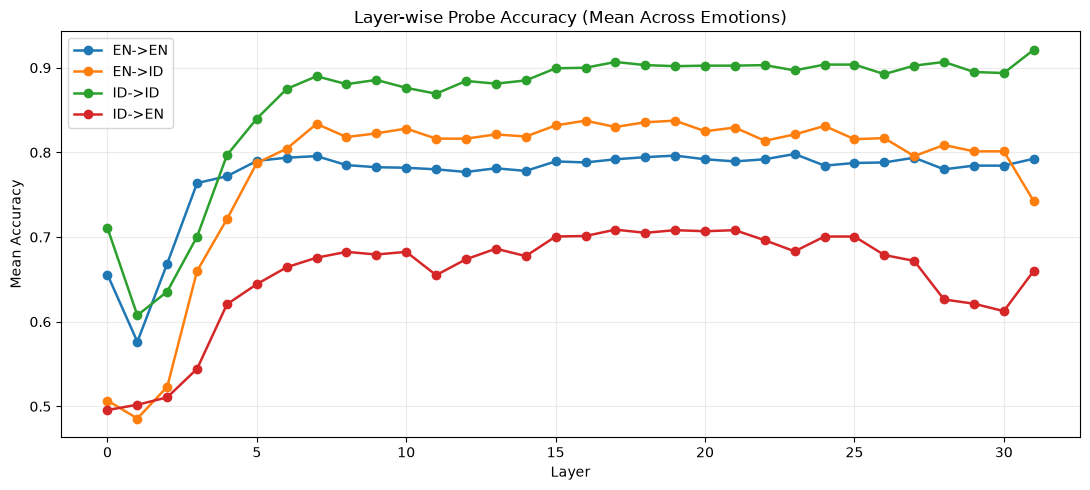

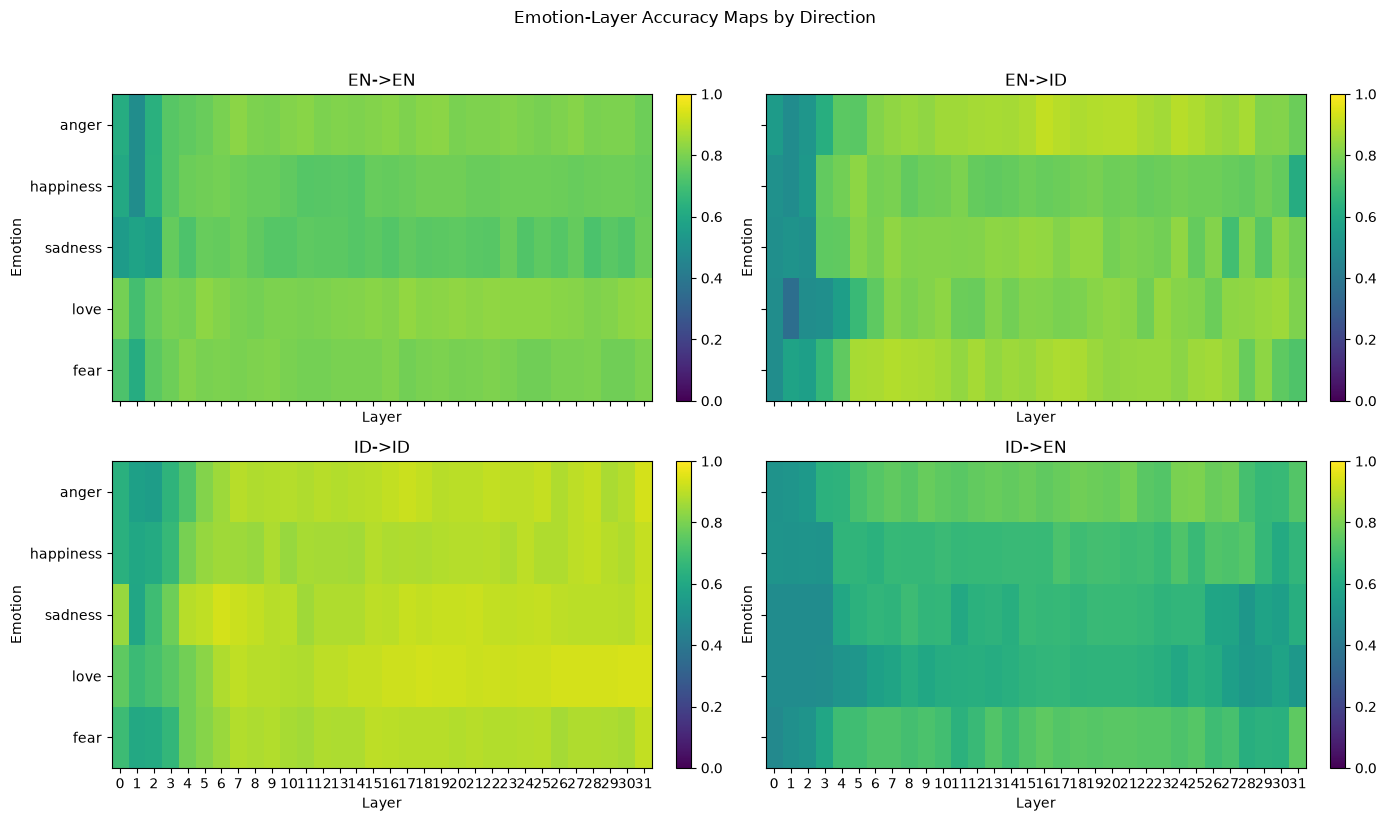

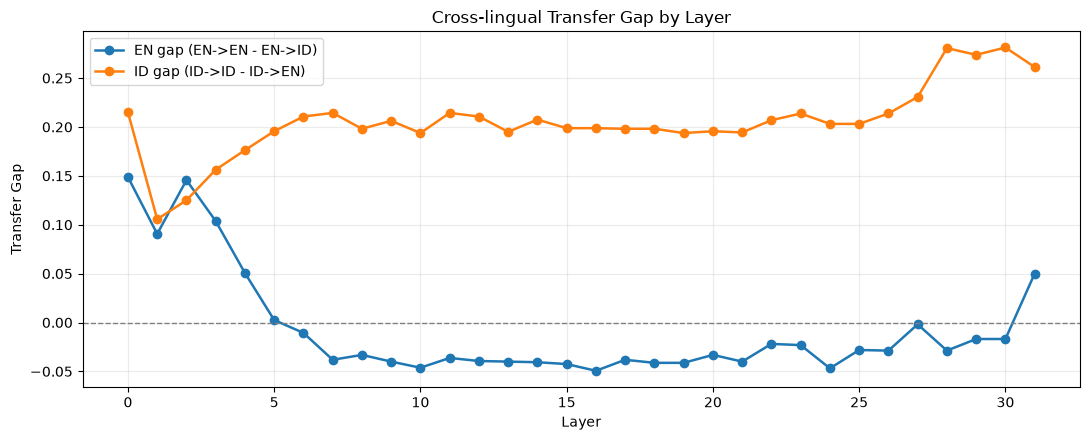

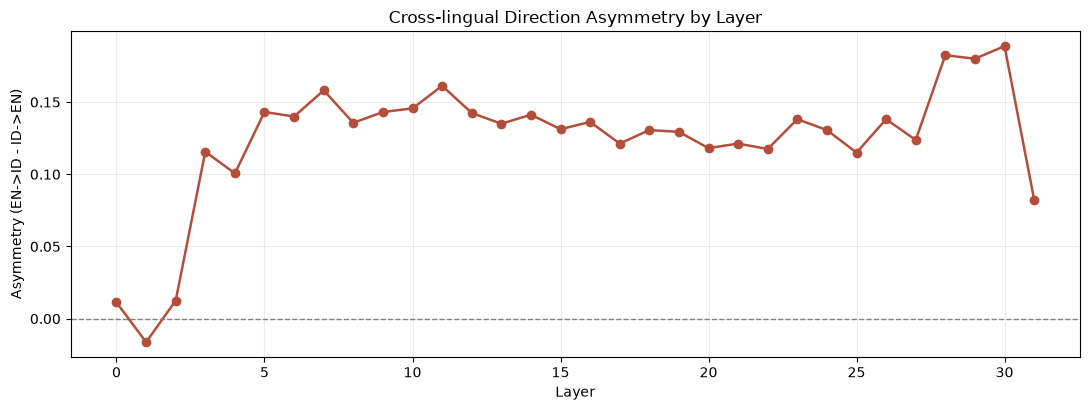

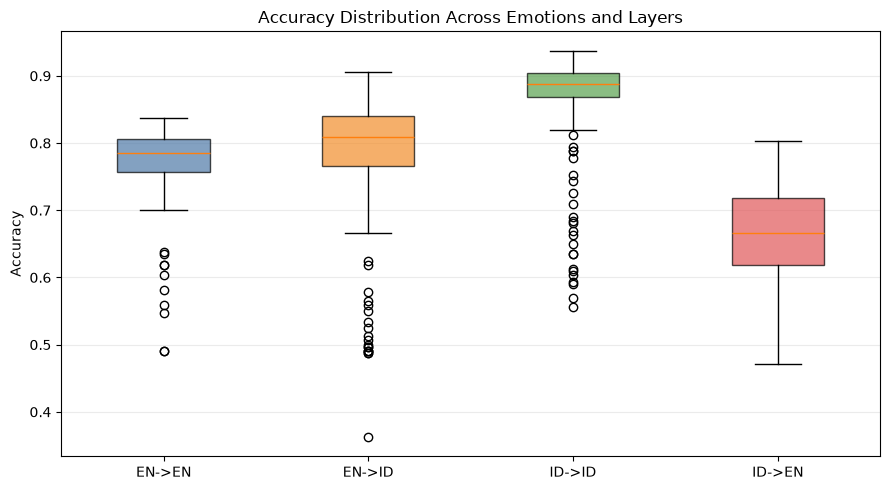

In [25]:
import matplotlib.pyplot as plt
import numpy as np

if "probe_results_df" not in globals():
    raise ValueError("Run the probe summary cell first to create probe_results_df.")

metric_cols = ["EN->EN", "EN->ID", "ID->ID", "ID->EN"]

# 1) Layer-wise overview (mean across emotions)
layer_avg_df = (
    probe_results_df.groupby("layer")[metric_cols]
    .mean()
    .reset_index()
)

plt.figure(figsize=(11, 5))
for col in metric_cols:
    plt.plot(layer_avg_df["layer"], layer_avg_df[col], marker="o", linewidth=1.8, label=col)
plt.xlabel("Layer")
plt.ylabel("Mean Accuracy")
plt.title("Layer-wise Probe Accuracy (Mean Across Emotions)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Emotion x Layer heatmaps for each direction
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for ax, col in zip(axes.ravel(), metric_cols):
    pivot = (
        probe_results_df
        .pivot(index="emotion", columns="layer", values=col)
        .reindex(all_emotions)
    )
    im = ax.imshow(pivot.values, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0)
    ax.set_title(col)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Emotion")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Emotion-Layer Accuracy Maps by Direction", y=1.02)
plt.tight_layout()
plt.show()

# 3) Transfer gap by layer
layer_avg_df["EN_gap"] = layer_avg_df["EN->EN"] - layer_avg_df["EN->ID"]
layer_avg_df["ID_gap"] = layer_avg_df["ID->ID"] - layer_avg_df["ID->EN"]

plt.figure(figsize=(11, 4.5))
plt.plot(layer_avg_df["layer"], layer_avg_df["EN_gap"], marker="o", linewidth=1.8, label="EN gap (EN->EN - EN->ID)")
plt.plot(layer_avg_df["layer"], layer_avg_df["ID_gap"], marker="o", linewidth=1.8, label="ID gap (ID->ID - ID->EN)")
plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Layer")
plt.ylabel("Transfer Gap")
plt.title("Cross-lingual Transfer Gap by Layer")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# 4) Directional asymmetry by layer
layer_avg_df["asymmetry"] = layer_avg_df["EN->ID"] - layer_avg_df["ID->EN"]

plt.figure(figsize=(11, 4.2))
plt.plot(layer_avg_df["layer"], layer_avg_df["asymmetry"], marker="o", linewidth=1.8, color="#B44E3A")
plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Layer")
plt.ylabel("Asymmetry (EN->ID - ID->EN)")
plt.title("Cross-lingual Direction Asymmetry by Layer")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 5) Distribution across emotions per direction
plot_data = [probe_results_df[col].values for col in metric_cols]

plt.figure(figsize=(9, 5))
box = plt.boxplot(plot_data, tick_labels=metric_cols, patch_artist=True)
colors = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.ylabel("Accuracy")
plt.title("Accuracy Distribution Across Emotions and Layers")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Statistical Analysis 

In [ ]:
# Eight-fold binary probing across selected layers using Indonesian Llama hidden states
all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']
layer_tests = list(range(1, 33))

probe_eng = create_performance_dict()
probe_id = create_performance_dict()

english_english_probe_performance = create_performance_dict()
english_indonesian_probe_performance = create_performance_dict()
indonesian_indonesian_probe_performance = create_performance_dict()
indonesian_english_probe_performance = create_performance_dict()

for layer in layer_tests:
    eng_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ID_eng[emotion][:, layer, :])
        for emotion in all_emotions
    }
    id_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ID_id[emotion][:, layer, :])
        for emotion in all_emotions
    }

    for emotion in all_emotions:
        # We create the dataloaders first 
        eng_folds = analysis.create_fold_dataloaders(
            emotion_dict=eng_layer_dict,
            emotion=emotion,
            seed=42,
            batch_size=50,
            k_folds=8,
        )
        id_folds = analysis.create_fold_dataloaders(
            emotion_dict=id_layer_dict,
            emotion=emotion,
            seed=42,
            batch_size=50,
            k_folds=8,
        )

        for (eng_train, eng_val), (id_train, id_val) in zip(eng_folds, id_folds):
            # Initialise the probe first
            probe_eng_model = analysis.LogisticRegressionProbe(
                input_dim=eng_layer_dict[emotion].shape[-1],
                output_dim=1,
            )
            probe_id_model = analysis.LogisticRegressionProbe(
                input_dim=id_layer_dict[emotion].shape[-1],
                output_dim=1,
            )

            # Train the proes 
            trained_eng_probe = analysis.trainProbe(probe_eng_model, eng_train, eng_val)
            trained_id_probe = analysis.trainProbe(probe_id_model, id_train, id_val)


            # Record the perfomance here
            english_english_probe_performance[layer][emotion].append(
                float(analysis.predictProbe(trained_eng_probe, eng_val).mean())
            )
            english_indonesian_probe_performance[layer][emotion].append(
                float(analysis.predictProbe(trained_eng_probe, id_val).mean())
            )
            indonesian_indonesian_probe_performance[layer][emotion].append(
                float(analysis.predictProbe(trained_id_probe, id_val).mean())
            )
            indonesian_english_probe_performance[layer][emotion].append(
                float(analysis.predictProbe(trained_id_probe, eng_val).mean())
            )

statistical_rows = []
performance_by_direction = {
    'EN->EN': english_english_probe_performance,
    'EN->ID': english_indonesian_probe_performance,
    'ID->ID': indonesian_indonesian_probe_performance,
    'ID->EN': indonesian_english_probe_performance,
}

for layer in layer_tests:
    for emotion in all_emotions:
        row = {'layer': layer, 'emotion': emotion}
        for direction, performance in performance_by_direction.items():
            fold_accuracies = performance[layer][emotion]
            row[f'{direction}_mean'] = float(np.mean(fold_accuracies))
            row[f'{direction}_std'] = float(np.std(fold_accuracies, ddof=1))
        statistical_rows.append(row)

statistical_probe_results_df = pd.DataFrame(statistical_rows)
display(statistical_probe_results_df)
print('Each layer/emotion contains 8 probes and 8 fold accuracies per direction.')

Epoch 1/10, Loss: 0.6968
Validation Accuracy: 0.5000
Epoch 2/10, Loss: 0.6932
Validation Accuracy: 0.5200
Epoch 3/10, Loss: 0.6914
Validation Accuracy: 0.6100
Epoch 4/10, Loss: 0.6931
Validation Accuracy: 0.5000
Epoch 5/10, Loss: 0.6934
Validation Accuracy: 0.5000
Epoch 6/10, Loss: 0.6872
Validation Accuracy: 0.5000
Epoch 7/10, Loss: 0.6875
Validation Accuracy: 0.6900
Epoch 8/10, Loss: 0.6858
Validation Accuracy: 0.7000
Epoch 9/10, Loss: 0.6850
Validation Accuracy: 0.5700
Epoch 10/10, Loss: 0.6855
Validation Accuracy: 0.7300
Epoch 1/10, Loss: 0.6957
Validation Accuracy: 0.5000
Epoch 2/10, Loss: 0.6916
Validation Accuracy: 0.5800
Epoch 3/10, Loss: 0.6885
Validation Accuracy: 0.5300
Epoch 4/10, Loss: 0.6881
Validation Accuracy: 0.5000
Epoch 5/10, Loss: 0.6872
Validation Accuracy: 0.5200
Epoch 6/10, Loss: 0.6849
Validation Accuracy: 0.5500
Epoch 7/10, Loss: 0.6824
Validation Accuracy: 0.5900
Epoch 8/10, Loss: 0.6812
Validation Accuracy: 0.5500
Epoch 9/10, Loss: 0.6799
Validation Accuracy:

IndexError: index 32 is out of bounds for axis 1 with size 32

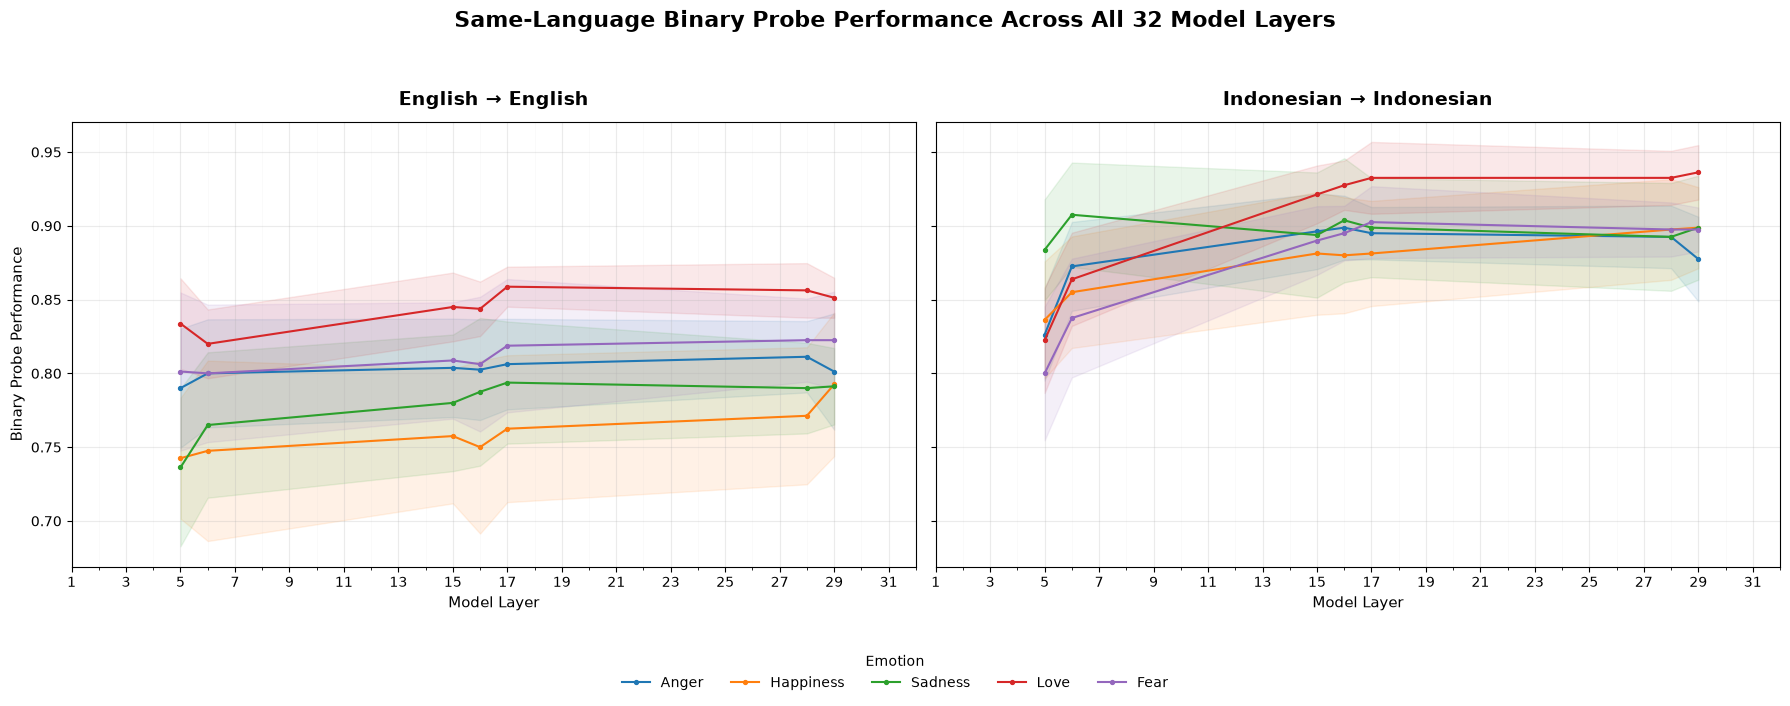

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

output_directory = Path("images/binary_probe_results")
output_directory.mkdir(parents=True, exist_ok=True)

same_language_directions = {
    "EN->EN": "English → English",
    "ID->ID": "Indonesian → Indonesian",
}

all_layers = list(range(1, 33))

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 7),
    sharex=True,
    sharey=True,
)

for ax, (direction, direction_title) in zip(
    axes,
    same_language_directions.items(),
):
    for emotion in all_emotions:
        emotion_df = (
            statistical_probe_results_df[
                statistical_probe_results_df["emotion"] == emotion
            ]
            .query("1 <= layer <= 32")
            .sort_values("layer")
            .copy()
        )

        layers = emotion_df["layer"].to_numpy()
        means = emotion_df[f"{direction}_mean"].to_numpy()
        stds = emotion_df[f"{direction}_std"].to_numpy()

        line = ax.plot(
            layers,
            means,
            marker="o",
            markersize=2.8,
            linewidth=1.5,
            label=emotion.title(),
        )[0]

        ax.fill_between(
            layers,
            means - stds,
            means + stds,
            color=line.get_color(),
            alpha=0.10,
        )

    ax.set_title(
        direction_title,
        fontsize=14,
        fontweight="bold",
        pad=12,
    )

    ax.set_xlabel("Model Layer", fontsize=11)

    # Include the complete layer range
    ax.set_xlim(1, 32)

    # Label every second layer to avoid overcrowding
    ax.set_xticks(range(1, 33, 2))

    # Keep a minor tick for every layer
    ax.set_xticks(all_layers, minor=True)

    ax.grid(
        axis="both",
        which="major",
        alpha=0.25,
        linewidth=0.8,
    )

    ax.grid(
        axis="x",
        which="minor",
        alpha=0.08,
        linewidth=0.5,
    )

axes[0].set_ylabel(
    "Binary Probe Performance",
    fontsize=11,
)

# One shared legend for both panels
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Emotion",
    loc="lower center",
    ncol=min(len(all_emotions), 5),
    bbox_to_anchor=(0.5, -0.01),
    frameon=False,
    fontsize=10,
    title_fontsize=10,
)

fig.suptitle(
    "Same-Language Binary Probe Performance Across All 32 Model Layers",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

fig.tight_layout(
    rect=[0, 0.10, 1, 0.94]
)

output_path = (
    output_directory
    / "same_language_probe_performance_all_32_layers.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

## Multi-Class Probe LLAMA Indonesian 

### Normal Train multiclass probes 

In [ ]:
# Train one multiclass probe per language and layer
all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']
total_layers = 32

multiclass_probe_en = {}
multiclass_probe_id = {}

english_english_multiclass_performance = {}
english_indonesian_multiclass_performance = {}
indonesian_indonesian_multiclass_performance = {}
indonesian_english_multiclass_performance = {}

for layer in range(total_layers):
    eng_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ID_eng[emotion][:, layer, :])
        for emotion in all_emotions
    }
    id_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ID_id[emotion][:, layer, :])
        for emotion in all_emotions
    }

    emotion_data_eng_train, emotion_data_eng_val = analysis.create_dataloader(
        emotion_dict=eng_layer_dict,
        emotion=all_emotions[0],
        val_ratio=0.4,
        multiclass=True,
        multiclass_emotions=all_emotions,
    )
    emotion_data_id_train, emotion_data_id_val = analysis.create_dataloader(
        emotion_dict=id_layer_dict,
        emotion=all_emotions[0],
        val_ratio=0.4,
        multiclass=True,
        multiclass_emotions=all_emotions,
    )

    probe_eng_model = analysis.LogisticRegressionProbe(
        input_dim=eng_layer_dict[all_emotions[0]].shape[-1],
        output_dim=len(all_emotions),
    )
    probe_id_model = analysis.LogisticRegressionProbe(
        input_dim=id_layer_dict[all_emotions[0]].shape[-1],
        output_dim=len(all_emotions),
    )

    multiclass_probe_en[layer] = analysis.trainMultiClassProbe(
        probe_eng_model,
        emotion_data_eng_train,
        emotion_data_eng_val,
        num_epochs=25,
    )
    multiclass_probe_id[layer] = analysis.trainMultiClassProbe(
        probe_id_model,
        emotion_data_id_train,
        emotion_data_id_val,
        num_epochs=25,
    )

    english_english_multiclass_performance[layer] = analysis.predictProbe(
        multiclass_probe_en[layer], emotion_data_eng_val, multiclass=True
    )
    english_indonesian_multiclass_performance[layer] = analysis.predictProbe(
        multiclass_probe_en[layer], emotion_data_id_val, multiclass=True
    )
    indonesian_indonesian_multiclass_performance[layer] = analysis.predictProbe(
        multiclass_probe_id[layer], emotion_data_id_val, multiclass=True
    )
    indonesian_english_multiclass_performance[layer] = analysis.predictProbe(
        multiclass_probe_id[layer], emotion_data_eng_val, multiclass=True
    )

multiclass_rows = []
for layer in range(total_layers):
    multiclass_rows.append({
        'layer': layer,
        'EN->EN': float(np.mean(english_english_multiclass_performance[layer])),
        'EN->ID': float(np.mean(english_indonesian_multiclass_performance[layer])),
        'ID->ID': float(np.mean(indonesian_indonesian_multiclass_performance[layer])),
        'ID->EN': float(np.mean(indonesian_english_multiclass_performance[layer])),
    })

multiclass_results_df = pd.DataFrame(multiclass_rows)
display(multiclass_results_df.head())
print(f'Trained English and Indonesian multiclass probes for {total_layers} layers.')

Epoch 1/25, Loss: 1.6082
Validation Accuracy: 0.3675
Epoch 2/25, Loss: 1.5986
Validation Accuracy: 0.3738
Epoch 3/25, Loss: 1.5901
Validation Accuracy: 0.3713
Epoch 4/25, Loss: 1.5830
Validation Accuracy: 0.4125
Epoch 5/25, Loss: 1.5745
Validation Accuracy: 0.4050
Epoch 6/25, Loss: 1.5675
Validation Accuracy: 0.4163
Epoch 7/25, Loss: 1.5597
Validation Accuracy: 0.4637
Epoch 8/25, Loss: 1.5513
Validation Accuracy: 0.4750
Epoch 9/25, Loss: 1.5452
Validation Accuracy: 0.4688
Epoch 10/25, Loss: 1.5368
Validation Accuracy: 0.4813
Epoch 11/25, Loss: 1.5294
Validation Accuracy: 0.4913
Epoch 12/25, Loss: 1.5221
Validation Accuracy: 0.4688
Epoch 13/25, Loss: 1.5162
Validation Accuracy: 0.5038
Epoch 14/25, Loss: 1.5079
Validation Accuracy: 0.5000
Epoch 15/25, Loss: 1.5010
Validation Accuracy: 0.5225
Epoch 16/25, Loss: 1.4942
Validation Accuracy: 0.5125
Epoch 17/25, Loss: 1.4872
Validation Accuracy: 0.5363
Epoch 18/25, Loss: 1.4824
Validation Accuracy: 0.4925
Epoch 19/25, Loss: 1.4731
Validation 

,layer,EN->EN,EN->ID,ID->ID,ID->EN
0,0,0.5450,0.20500,0.72875,0.22250
1,1,0.4100,0.20750,0.65000,0.21750
2,2,0.5125,0.36125,0.73375,0.34500
3,3,0.6550,0.56875,0.83000,0.41375
4,4,0.6800,0.73250,0.86375,0.55250


Trained multiclass probes for 32 layers
Cached probes: multiclass_probe_en and multiclass_probe_id


### Print results 

,layer,EN->EN,EN->ID,ID->ID,ID->EN
0,0,0.54125,0.20375,0.72000,0.22125
1,1,0.45500,0.19125,0.66375,0.21750
2,2,0.57625,0.35500,0.76125,0.23000
3,3,0.66500,0.51750,0.82125,0.43375
4,4,0.66375,0.72625,0.86000,0.56250
5,5,0.65875,0.78500,0.87375,0.57000
6,6,0.67250,0.78750,0.90625,0.59875
7,7,0.67750,0.76625,0.91125,0.59250
8,8,0.67875,0.78875,0.90750,0.57500
9,9,0.67250,0.77750,0.89750,0.56500



Best layer per direction:
EN->EN: layer 19, mean acc 0.7063
EN->ID: layer 8, mean acc 0.7887
ID->ID: layer 19, mean acc 0.9125
ID->EN: layer 6, mean acc 0.5988


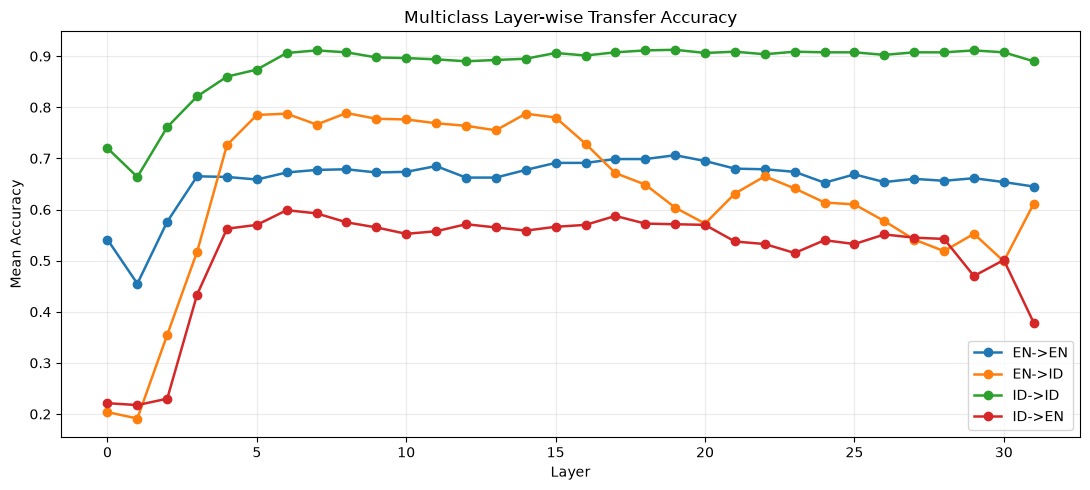

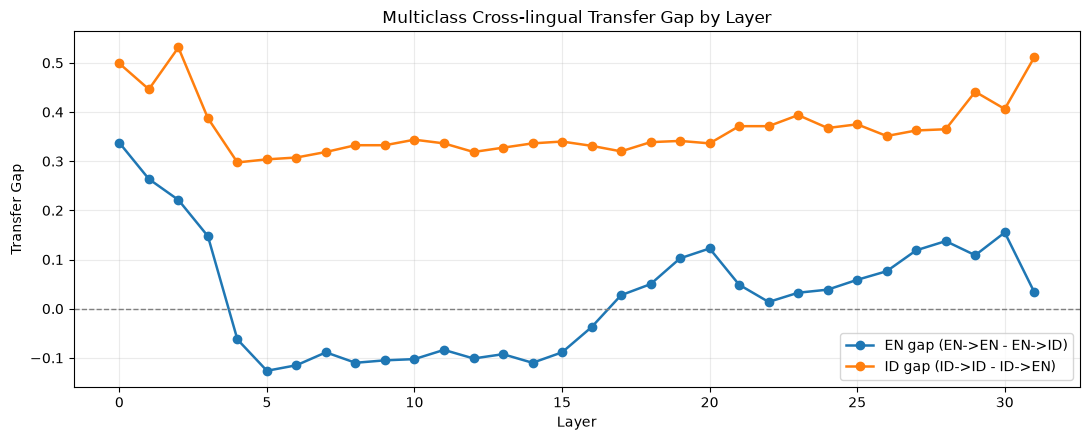

In [31]:
# Print + display multiclass results across all layers
if "multiclass_results_df" not in globals():
    raise ValueError("Run the multiclass training cell first.")

display(multiclass_results_df)

print("\nBest layer per direction:")
for col in ["EN->EN", "EN->ID", "ID->ID", "ID->EN"]:
    best_idx = multiclass_results_df[col].idxmax()
    print(f"{col}: layer {int(multiclass_results_df.loc[best_idx, 'layer'])}, mean acc {multiclass_results_df.loc[best_idx, col]:.4f}")

# Plot similar style to binary section
plt.figure(figsize=(11, 5))
for col in ["EN->EN", "EN->ID", "ID->ID", "ID->EN"]:
    plt.plot(multiclass_results_df["layer"], multiclass_results_df[col], marker="o", linewidth=1.8, label=col)
plt.xlabel("Layer")
plt.ylabel("Mean Accuracy")
plt.title("Multiclass Layer-wise Transfer Accuracy")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

multiclass_results_df["EN_gap"] = multiclass_results_df["EN->EN"] - multiclass_results_df["EN->ID"]
multiclass_results_df["ID_gap"] = multiclass_results_df["ID->ID"] - multiclass_results_df["ID->EN"]

plt.figure(figsize=(11, 4.5))
plt.plot(multiclass_results_df["layer"], multiclass_results_df["EN_gap"], marker="o", linewidth=1.8, label="EN gap (EN->EN - EN->ID)")
plt.plot(multiclass_results_df["layer"], multiclass_results_df["ID_gap"], marker="o", linewidth=1.8, label="ID gap (ID->ID - ID->EN)")
plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Layer")
plt.ylabel("Transfer Gap")
plt.title("Multiclass Cross-lingual Transfer Gap by Layer")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

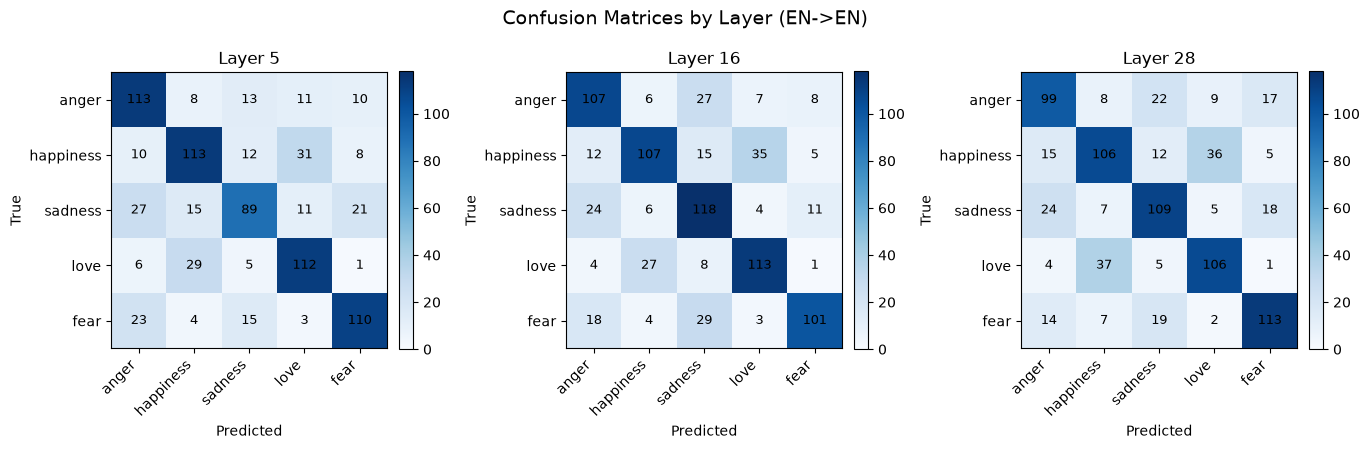

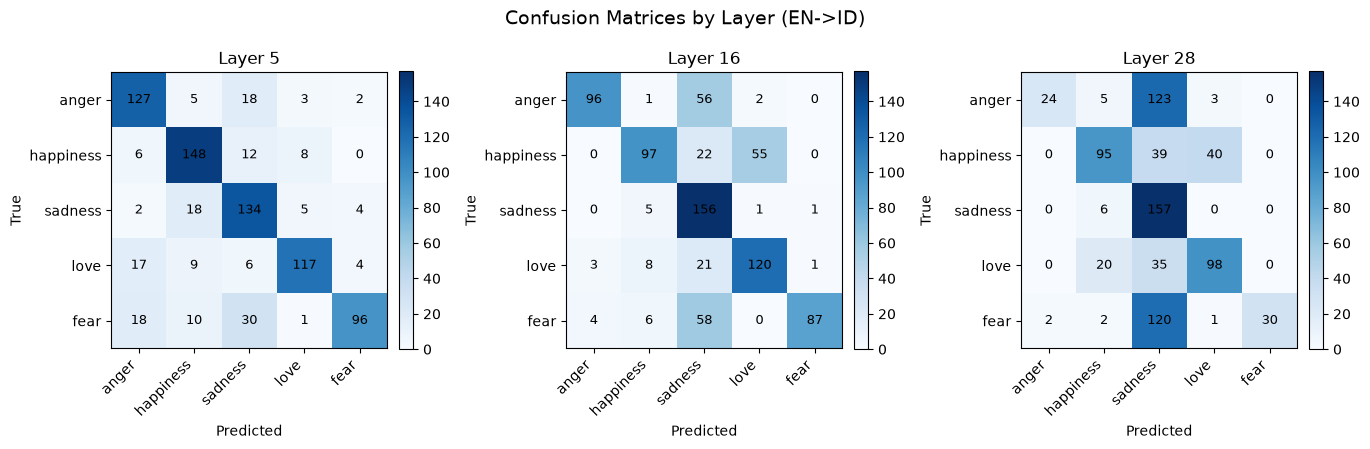

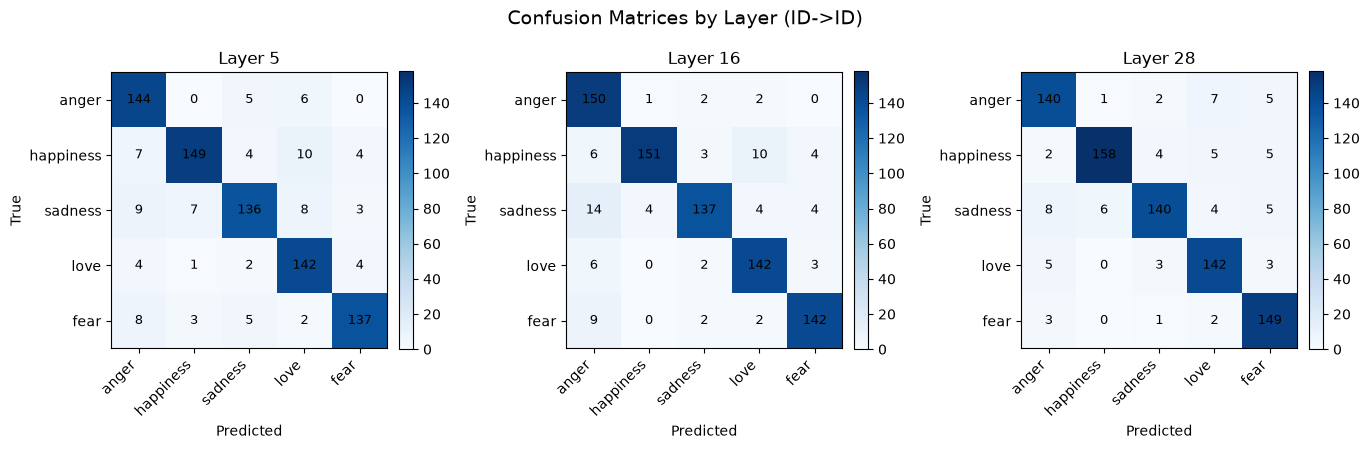

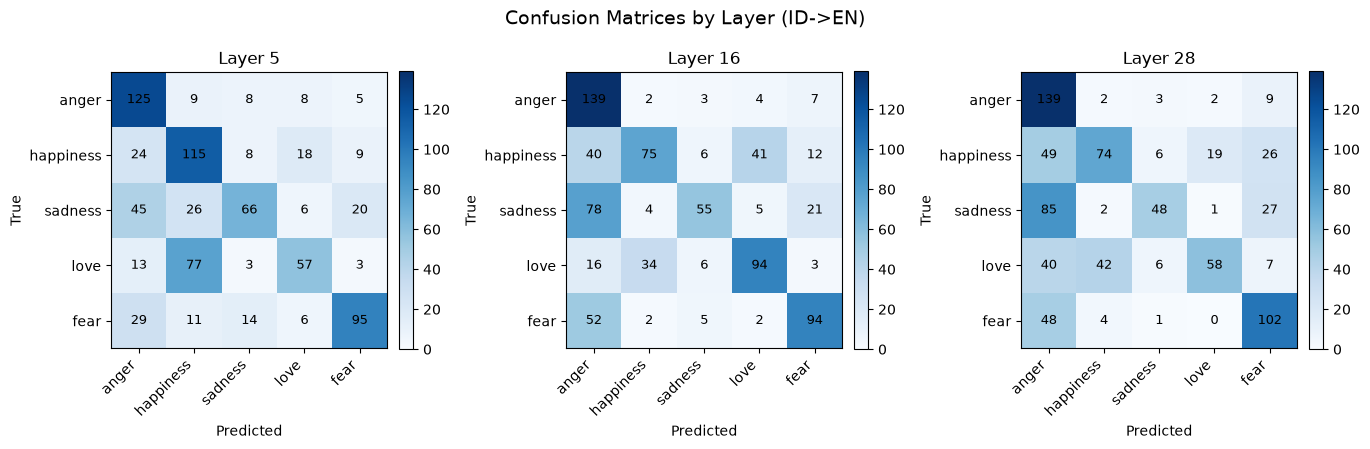

In [11]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix

# -----------------------------
# Config
# -----------------------------
layers_to_plot = [5, 16, 28]   # <- edit this list as needed
normalize = False              # set True for row-normalized confusion matrices

if "all_emotions" not in globals():
    raise ValueError("Missing all_emotions.")
if "mdfLLAMAD_ID_eng" not in globals() or "mdfLLAMAD_ID_id" not in globals():
    raise ValueError("Run data preparation cells first.")
if "analysis" not in globals():
    raise ValueError("Missing analysis module.")
if "multiclass_probe_en" not in globals() or "multiclass_probe_id" not in globals():
    raise ValueError("Run the multiclass training cell first so cached probes (multiclass_probe_en/multiclass_probe_id) are available.")

# Store confusion matrices: cm_store[direction][layer] = cm
directions = ["EN->EN", "EN->ID", "ID->ID", "ID->EN"]
cm_store = {d: {} for d in directions}

def _collect_preds_labels(model, loader):
    preds, labels = [], []
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(pred.tolist())
            labels.extend(y_batch.numpy().tolist())
    return np.array(labels), np.array(preds)

for layer in layers_to_plot:
    if layer not in multiclass_probe_en or layer not in multiclass_probe_id:
        raise ValueError(f"Layer {layer} not found in cached probes. Re-run multiclass training cell.")

    # Rebuild per-layer val loaders (probe is reused; no retraining here)
    emotion_vector_eng = {emo: mdfLLAMAD_ID_eng[emo][:, layer, :] for emo in all_emotions}
    emotion_vector_id  = {emo: mdfLLAMAD_ID_id[emo][:, layer, :] for emo in all_emotions}

    _, eng_val = analysis.create_dataloader(
        emotion_vector_eng,
        emotion=all_emotions[0],
        val_ratio=0.4,
        multiclass=True,
        multiclass_emotions=all_emotions,
    )
    _, id_val = analysis.create_dataloader(
        emotion_vector_id,
        emotion=all_emotions[0],
        val_ratio=0.4,
        multiclass=True,
        multiclass_emotions=all_emotions,
    )

    probe_en = multiclass_probe_en[layer]
    probe_id = multiclass_probe_id[layer]

    # Predictions for all four directions using existing trained probes
    y_true_en, y_pred_en_from_en = _collect_preds_labels(probe_en, eng_val)  # EN->EN
    y_true_id, y_pred_id_from_en = _collect_preds_labels(probe_en, id_val)   # EN->ID
    y_true_id2, y_pred_id_from_id = _collect_preds_labels(probe_id, id_val)  # ID->ID
    y_true_en2, y_pred_en_from_id = _collect_preds_labels(probe_id, eng_val) # ID->EN

    cm_store["EN->EN"][layer] = confusion_matrix(y_true_en,  y_pred_en_from_en, labels=range(len(all_emotions)))
    cm_store["EN->ID"][layer] = confusion_matrix(y_true_id,  y_pred_id_from_en, labels=range(len(all_emotions)))
    cm_store["ID->ID"][layer] = confusion_matrix(y_true_id2, y_pred_id_from_id, labels=range(len(all_emotions)))
    cm_store["ID->EN"][layer] = confusion_matrix(y_true_en2, y_pred_en_from_id, labels=range(len(all_emotions)))

# Optional normalization
if normalize:
    for d in directions:
        for layer in layers_to_plot:
            cm = cm_store[d][layer].astype(float)
            row_sums = cm.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1.0
            cm_store[d][layer] = cm / row_sums

# -----------------------------
# Plot: one figure per direction
# -----------------------------
for direction in directions:
    n = len(layers_to_plot)
    ncols = min(4, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.2 * nrows), squeeze=False)
    fig.suptitle(f"Confusion Matrices by Layer ({direction})", fontsize=14, y=1.02)

    vmax = 1.0 if normalize else max(cm_store[direction][ly].max() for ly in layers_to_plot)

    for i, layer in enumerate(layers_to_plot):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        cm = cm_store[direction][layer]

        im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=vmax)
        ax.set_title(f"Layer {layer}")
        ax.set_xticks(range(len(all_emotions)))
        ax.set_yticks(range(len(all_emotions)))
        ax.set_xticklabels(all_emotions, rotation=45, ha="right")
        ax.set_yticklabels(all_emotions)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

        for rr in range(cm.shape[0]):
            for cc in range(cm.shape[1]):
                txt = f"{cm[rr, cc]:.2f}" if normalize else f"{int(cm[rr, cc])}"
                ax.text(cc, rr, txt, ha="center", va="center", fontsize=9, color="black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Hide unused axes
    for j in range(len(layers_to_plot), nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].axis("off")

    plt.tight_layout()
    plt.show()

### Statistical analysis 

In [18]:
# Eight-fold multiclass probing across selected layers
all_emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']
layer_tests = list(range(32))
multiclass_label = 'all_emotions'

multiprobe_eng = create_performance_dict()
multiprobe_id = create_performance_dict()

english_english_multiprobe_performance = create_performance_dict()
english_indonesian_multiprobe_performance = create_performance_dict()
indonesian_indonesian_multiprobe_performance = create_performance_dict()
indonesian_english_multiprobe_performance = create_performance_dict()

for layer in layer_tests:
    eng_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ID_eng[emotion][:, layer, :])
        for emotion in all_emotions
    }
    id_layer_dict = {
        emotion: torch.from_numpy(mdfLLAMAD_ID_id[emotion][:, layer, :])
        for emotion in all_emotions
    }

    eng_folds = analysis.create_fold_dataloaders(
        emotion_dict=eng_layer_dict,
        emotion=all_emotions[0],
        seed=42,
        batch_size=50,
        k_folds=8,
        multiclass=True,
        multiclass_emotions=all_emotions,
    )
    id_folds = analysis.create_fold_dataloaders(
        emotion_dict=id_layer_dict,
        emotion=all_emotions[0],
        seed=42,
        batch_size=50,
        k_folds=8,
        multiclass=True,
        multiclass_emotions=all_emotions,
    )

    for (eng_train, eng_val), (id_train, id_val) in zip(eng_folds, id_folds):
        probe_eng_model = analysis.LogisticRegressionProbe(
            input_dim=eng_layer_dict[all_emotions[0]].shape[-1],
            output_dim=len(all_emotions),
        )
        probe_id_model = analysis.LogisticRegressionProbe(
            input_dim=id_layer_dict[all_emotions[0]].shape[-1],
            output_dim=len(all_emotions),
        )

        trained_eng_probe = analysis.trainMultiClassProbe(
            probe_eng_model, eng_train, eng_val, num_epochs=25
        )
        trained_id_probe = analysis.trainMultiClassProbe(
            probe_id_model, id_train, id_val, num_epochs=25
        )

        multiprobe_eng[layer][multiclass_label].append(trained_eng_probe)
        multiprobe_id[layer][multiclass_label].append(trained_id_probe)

        english_english_multiprobe_performance[layer][multiclass_label].append(
            float(analysis.predictProbe(trained_eng_probe, eng_val, multiclass=True).mean())
        )
        english_indonesian_multiprobe_performance[layer][multiclass_label].append(
            float(analysis.predictProbe(trained_eng_probe, id_val, multiclass=True).mean())
        )
        indonesian_indonesian_multiprobe_performance[layer][multiclass_label].append(
            float(analysis.predictProbe(trained_id_probe, id_val, multiclass=True).mean())
        )
        indonesian_english_multiprobe_performance[layer][multiclass_label].append(
            float(analysis.predictProbe(trained_id_probe, eng_val, multiclass=True).mean())
        )

multiclass_statistical_rows = []
for layer in layer_tests:
    multiclass_statistical_rows.append({
        'layer': layer,
        'EN_EN_mean': float(np.mean(english_english_multiprobe_performance[layer][multiclass_label])),
        'EN_EN_std': float(np.std(english_english_multiprobe_performance[layer][multiclass_label], ddof=1)),
        'EN_ID_mean': float(np.mean(english_indonesian_multiprobe_performance[layer][multiclass_label])),
        'EN_ID_std': float(np.std(english_indonesian_multiprobe_performance[layer][multiclass_label], ddof=1)),
        'ID_ID_mean': float(np.mean(indonesian_indonesian_multiprobe_performance[layer][multiclass_label])),
        'ID_ID_std': float(np.std(indonesian_indonesian_multiprobe_performance[layer][multiclass_label], ddof=1)),
        'ID_EN_mean': float(np.mean(indonesian_english_multiprobe_performance[layer][multiclass_label])),
        'ID_EN_std': float(np.std(indonesian_english_multiprobe_performance[layer][multiclass_label], ddof=1)),
    })

multiclass_statistical_results_df = pd.DataFrame(multiclass_statistical_rows)
display(multiclass_statistical_results_df)

multiclass_fold_rows = []
for layer in layer_tests:
    for fold_index in range(8):
        multiclass_fold_rows.append({
            'layer': layer,
            'fold': fold_index + 1,
            'EN_EN': english_english_multiprobe_performance[layer][multiclass_label][fold_index],
            'EN_ID': english_indonesian_multiprobe_performance[layer][multiclass_label][fold_index],
            'ID_ID': indonesian_indonesian_multiprobe_performance[layer][multiclass_label][fold_index],
            'ID_EN': indonesian_english_multiprobe_performance[layer][multiclass_label][fold_index],
        })

multiclass_fold_results_df = pd.DataFrame(multiclass_fold_rows)
display(multiclass_fold_results_df)
print('Stored 8 English and 8 Indonesian multiclass probes for each selected layer.')

Epoch 1/25, Loss: 1.6069
Validation Accuracy: 0.4480
Epoch 2/25, Loss: 1.5980
Validation Accuracy: 0.4600
Epoch 3/25, Loss: 1.5892
Validation Accuracy: 0.4040
Epoch 4/25, Loss: 1.5808
Validation Accuracy: 0.4760
Epoch 5/25, Loss: 1.5725
Validation Accuracy: 0.4480
Epoch 6/25, Loss: 1.5638
Validation Accuracy: 0.5320
Epoch 7/25, Loss: 1.5565
Validation Accuracy: 0.4960
Epoch 8/25, Loss: 1.5487
Validation Accuracy: 0.5280
Epoch 9/25, Loss: 1.5405
Validation Accuracy: 0.5080
Epoch 10/25, Loss: 1.5332
Validation Accuracy: 0.5240
Epoch 11/25, Loss: 1.5258
Validation Accuracy: 0.5320
Epoch 12/25, Loss: 1.5186
Validation Accuracy: 0.5200
Epoch 13/25, Loss: 1.5107
Validation Accuracy: 0.5360
Epoch 14/25, Loss: 1.5037
Validation Accuracy: 0.5360
Epoch 15/25, Loss: 1.4969
Validation Accuracy: 0.5360
Epoch 16/25, Loss: 1.4895
Validation Accuracy: 0.5360
Epoch 17/25, Loss: 1.4829
Validation Accuracy: 0.5360
Epoch 18/25, Loss: 1.4751
Validation Accuracy: 0.5360
Epoch 19/25, Loss: 1.4686
Validation 

,layer,EN_EN_mean,EN_EN_std,EN_ID_mean,EN_ID_std,ID_ID_mean,ID_ID_std,ID_EN_mean,ID_EN_std
0,0,0.5920,0.017889,0.2225,0.009304,0.7365,0.023658,0.2095,0.010461
1,1,0.4970,0.027360,0.2440,0.028284,0.6935,0.039246,0.2290,0.023003
2,2,0.5945,0.039130,0.3225,0.041235,0.7795,0.023561,0.2420,0.022526
3,3,0.6585,0.023022,0.5075,0.052304,0.8340,0.027877,0.3805,0.045879
4,4,0.6850,0.015964,0.7230,0.042426,0.8715,0.016484,0.5560,0.015566
5,5,0.6900,0.021166,0.7640,0.027464,0.8910,0.016937,0.5720,0.025298
6,6,0.6990,0.020922,0.7950,0.030369,0.9165,0.010784,0.5800,0.036661
7,7,0.7000,0.014813,0.8050,0.024634,0.9115,0.022367,0.5830,0.038649
8,8,0.6955,0.022672,0.8025,0.034933,0.9090,0.024727,0.5785,0.036719
9,9,0.6835,0.031528,0.7760,0.032071,0.9040,0.021488,0.5675,0.041096


,layer,fold,EN_EN,EN_ID,ID_ID,ID_EN
0,0,1,0.572,0.232,0.760,0.204
1,0,2,0.604,0.220,0.724,0.204
2,0,3,0.568,0.232,0.740,0.228
3,0,4,0.592,0.212,0.692,0.204
4,0,5,0.620,0.232,0.756,0.200
...,...,...,...,...,...,...
251,31,4,0.652,0.540,0.916,0.452
252,31,5,0.676,0.612,0.924,0.480
253,31,6,0.692,0.512,0.888,0.488
254,31,7,0.636,0.592,0.928,0.488


Stored 8 English and 8 Indonesian multiclass probes for each selected layer.


In [17]:
print(multiclass_statistical_results_df["layer"].tolist())
print("Number of layers:", multiclass_statistical_results_df["layer"].nunique())

[5, 6, 15, 16, 17, 28, 29]
Number of layers: 7


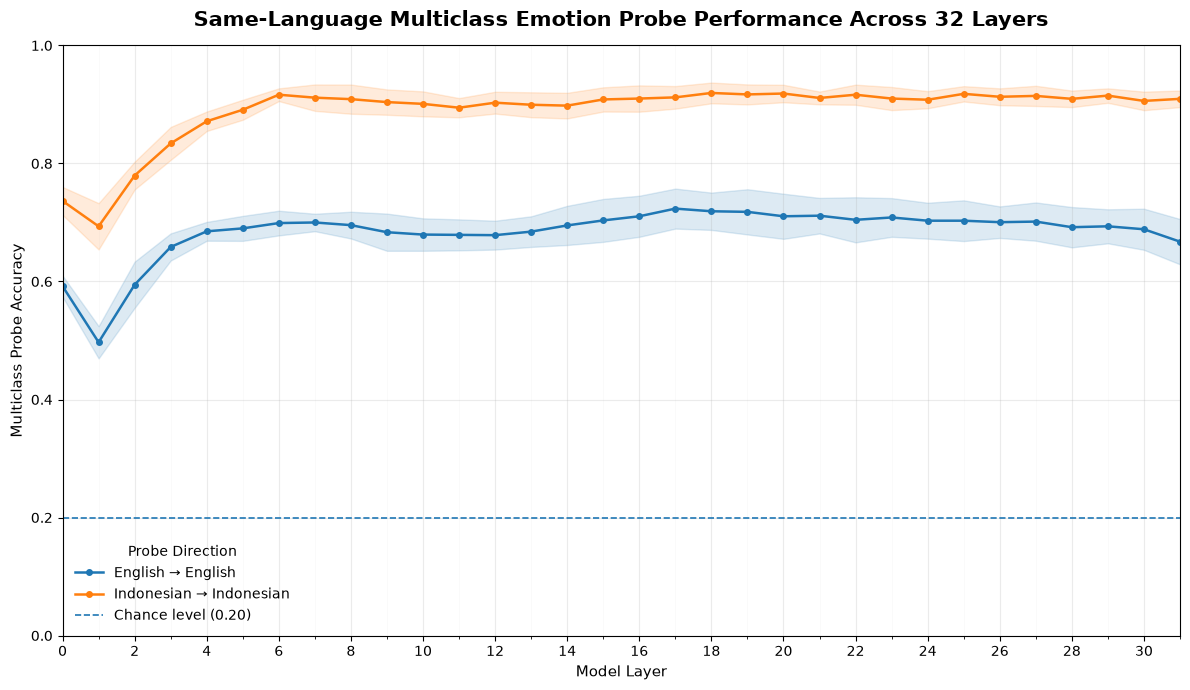

In [20]:
import matplotlib.pyplot as plt
from pathlib import Path

output_directory = Path("images/multiclass_probe_results")
output_directory.mkdir(parents=True, exist_ok=True)

same_language_directions = {
    "EN_EN": "English → English",
    "ID_ID": "Indonesian → Indonesian",
}

all_layers = list(range(32))
chance_accuracy = 1 / len(all_emotions)  # 0.20 for five emotions

plot_df = (
    multiclass_statistical_results_df[
        multiclass_statistical_results_df["layer"].between(0, 31)
    ]
    .sort_values("layer")
    .copy()
)

fig, ax = plt.subplots(
    figsize=(12, 7),
)

for direction, direction_label in same_language_directions.items():
    layers = plot_df["layer"].to_numpy()
    means = plot_df[f"{direction}_mean"].to_numpy()
    stds = plot_df[f"{direction}_std"].to_numpy()

    line = ax.plot(
        layers,
        means,
        marker="o",
        markersize=4,
        linewidth=1.8,
        label=direction_label,
    )[0]

    ax.fill_between(
        layers,
        means - stds,
        means + stds,
        color=line.get_color(),
        alpha=0.15,
    )

# Five-class chance-level accuracy
ax.axhline(
    y=chance_accuracy,
    linestyle="--",
    linewidth=1.2,
    label=f"Chance level ({chance_accuracy:.2f})",
)

ax.set_title(
    "Same-Language Multiclass Emotion Probe Performance Across 32 Layers",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(
    "Model Layer",
    fontsize=11,
)

ax.set_ylabel(
    "Multiclass Probe Accuracy",
    fontsize=11,
)

ax.set_xlim(0, 31)
ax.set_ylim(0, 1.0)

# Show numbered labels every two layers
ax.set_xticks(range(0, 32, 2))

# Keep a minor tick at every layer
ax.set_xticks(all_layers, minor=True)

ax.grid(
    axis="both",
    which="major",
    alpha=0.25,
    linewidth=0.8,
)

ax.grid(
    axis="x",
    which="minor",
    alpha=0.08,
    linewidth=0.5,
)

ax.legend(
    title="Probe Direction",
    loc="best",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
)

fig.tight_layout()

output_path = (
    output_directory
    / "combined_same_language_multiclass_probe_performance.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

# Cosine Similarity Different Steering Vectors

## Simple Cosine Similarity 

,anger,happiness,sadness,love,fear
anger,1.000000,-0.576407,0.240190,-0.585441,0.246262
happiness,-0.576407,1.000000,-0.658050,0.802629,-0.785488
sadness,0.240190,-0.658050,1.000000,-0.716025,0.617899
love,-0.585441,0.802629,-0.716025,1.000000,-0.835307
fear,0.246262,-0.785488,0.617899,-0.835307,1.000000


,anger,happiness,sadness,love,fear
anger,1.000000,0.681433,-0.607531,-0.858010,0.830862
happiness,0.681433,1.000000,-0.678881,-0.923080,0.821376
sadness,-0.607531,-0.678881,1.000000,0.624432,-0.596288
love,-0.858010,-0.923080,0.624432,1.000000,-0.946293
fear,0.830862,0.821376,-0.596288,-0.946293,1.000000


,anger,happiness,sadness,love,fear
anger,1.000000,-0.540299,0.150357,-0.606983,0.180175
happiness,-0.540299,1.000000,-0.468606,0.689461,-0.698363
sadness,0.150357,-0.468606,1.000000,-0.552729,0.385775
love,-0.606983,0.689461,-0.552729,1.000000,-0.726888
fear,0.180175,-0.698363,0.385775,-0.726888,1.000000


,anger,happiness,sadness,love,fear
anger,1.000000,0.539459,-0.472251,-0.802478,0.779238
happiness,0.539459,1.000000,-0.557660,-0.876245,0.732379
sadness,-0.472251,-0.557660,1.000000,0.478299,-0.468030
love,-0.802478,-0.876245,0.478299,1.000000,-0.925610
fear,0.779238,0.732379,-0.468030,-0.925610,1.000000


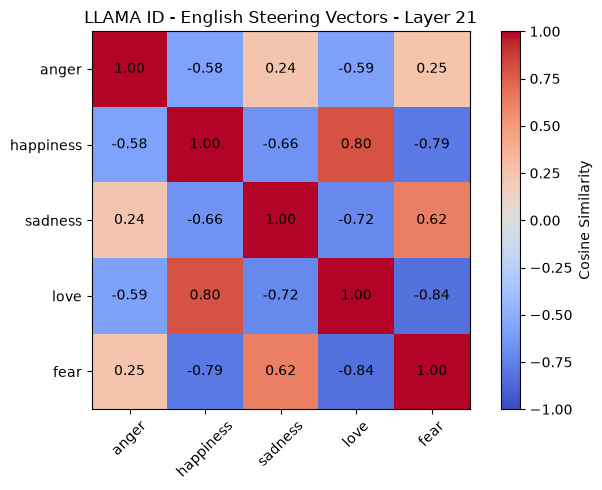

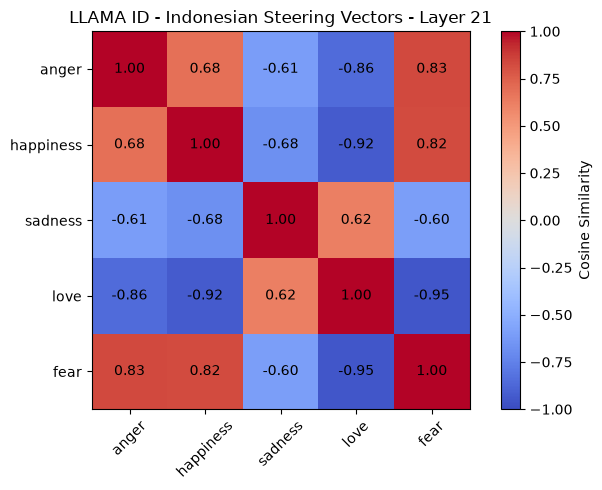

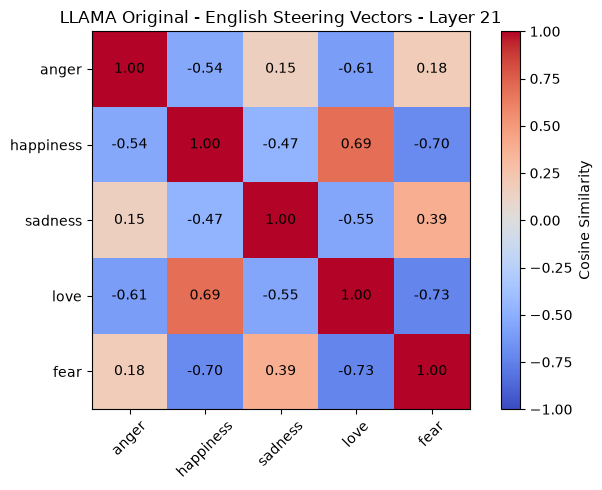

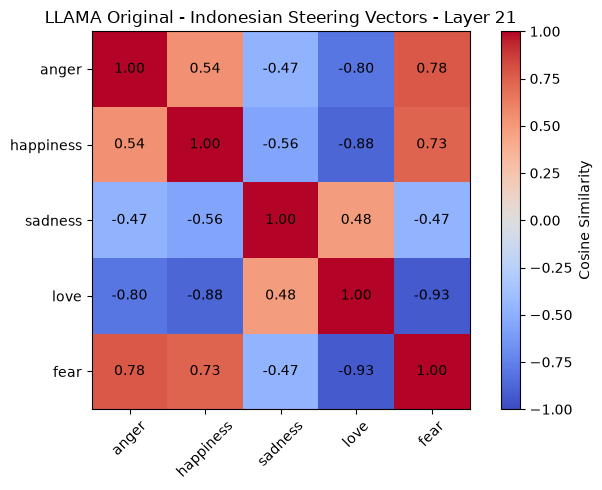

In [4]:



import matplotlib.pyplot as plt

emotions = ['anger', 'happiness', 'sadness', 'love', 'fear']
layer_idx = 21

LLAMAID_eng_cosine_matrix = analysis.build_cosine_matrix(Llama_indo_steering_vector_eng, emotions, layer_idx)
LLAMAID_id_cosine_matrix = analysis.build_cosine_matrix(Llama_indo_steering_vector_id, emotions, layer_idx)

LLAMAENG_eng_cosine_matrix = analysis.build_cosine_matrix(Llama_eng_steering_vector_eng, emotions, layer_idx)
LLAMAENG_id_cosine_matrix = analysis.build_cosine_matrix(Llama_eng_steering_vector_id, emotions, layer_idx)


display(LLAMAID_eng_cosine_matrix)
display(LLAMAID_id_cosine_matrix)
display(LLAMAENG_eng_cosine_matrix)
display(LLAMAENG_id_cosine_matrix)


# LLAMA ID (Indonesian) - Layer 21
plt.figure(figsize=(7, 5))
eng_plot = plt.imshow(LLAMAID_eng_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('LLAMA ID - English Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), LLAMAID_eng_cosine_matrix.values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
id_plot = plt.imshow(LLAMAID_id_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('LLAMA ID - Indonesian Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), LLAMAID_id_cosine_matrix.values)
plt.tight_layout()
plt.show()

# LLAMA Original (English) - Layer 21
plt.figure(figsize=(7, 5))
eng_plot = plt.imshow(LLAMAENG_eng_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('LLAMA Original - English Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), LLAMAENG_eng_cosine_matrix.values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
id_plot = plt.imshow(LLAMAENG_id_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(emotions)), emotions, rotation=45)
plt.yticks(range(len(emotions)), emotions)
plt.title('LLAMA Original - Indonesian Steering Vectors - Layer 21')
analysis.annotate_heatmap(plt.gca(), LLAMAENG_id_cosine_matrix.values)
plt.tight_layout()
plt.show()


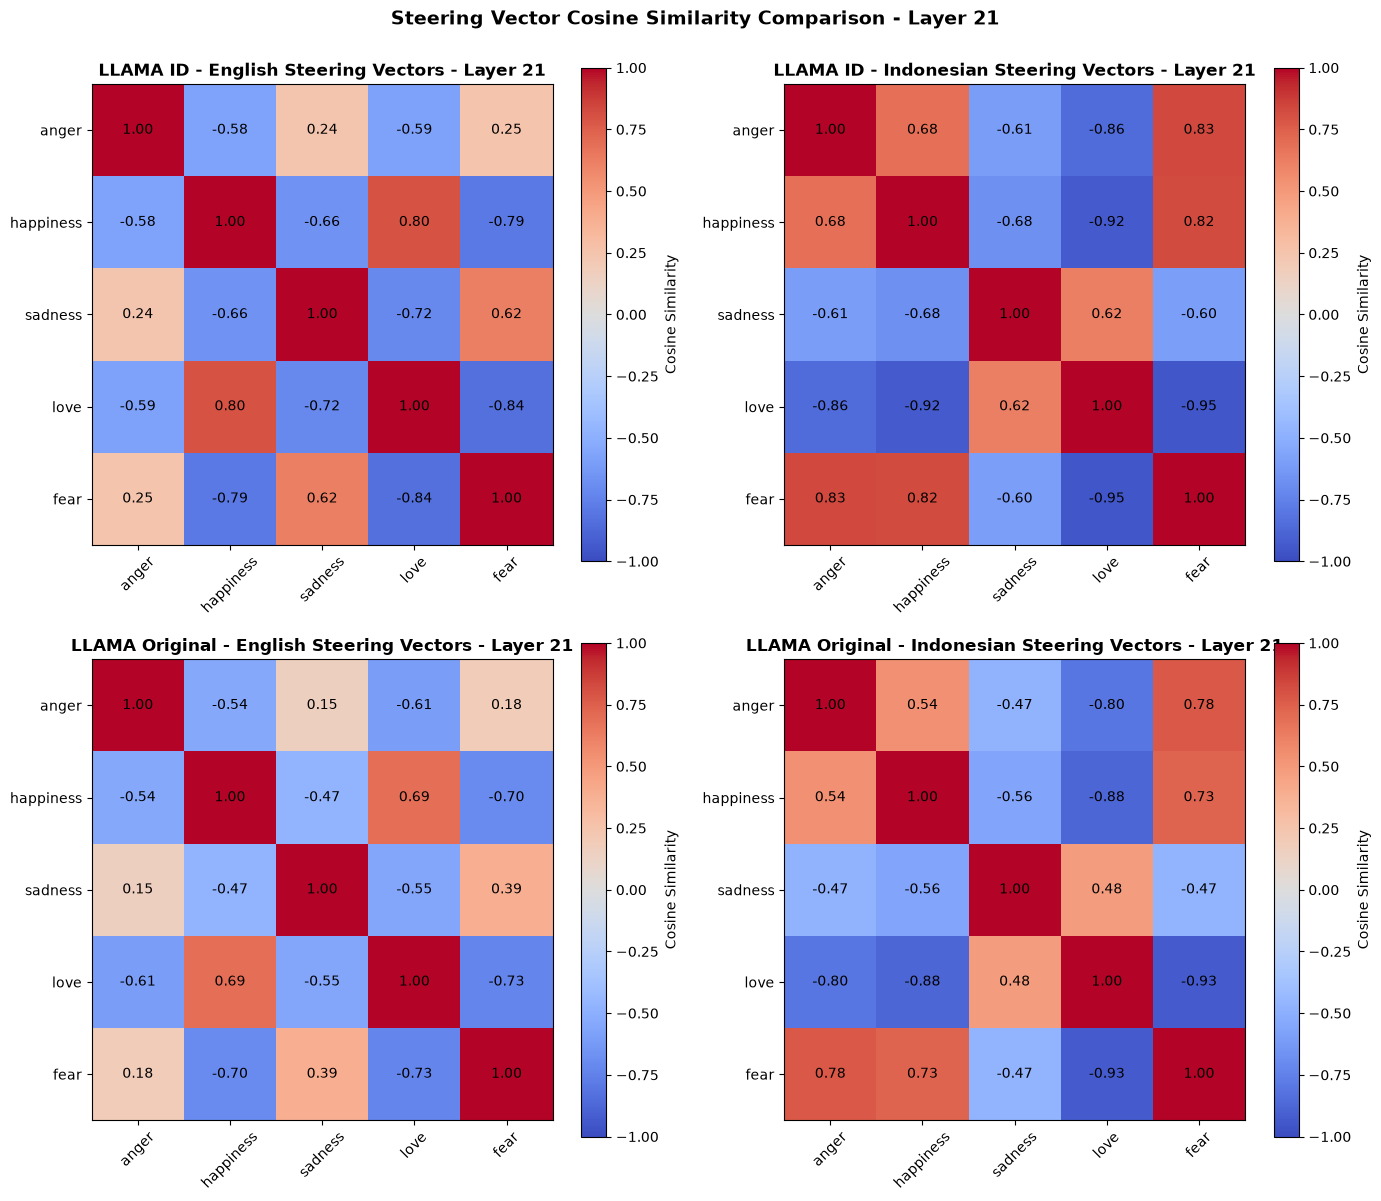

In [6]:

# All four matrices in one figure
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# LLAMA ID - English
im1 = axes[0, 0].imshow(LLAMAID_eng_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
axes[0, 0].set_xticks(range(len(emotions)))
axes[0, 0].set_yticks(range(len(emotions)))
axes[0, 0].set_xticklabels(emotions, rotation=45)
axes[0, 0].set_yticklabels(emotions)
axes[0, 0].set_title('LLAMA ID - English Steering Vectors - Layer 21', fontsize=12, fontweight='bold')
analysis.annotate_heatmap(axes[0, 0], LLAMAID_eng_cosine_matrix.values)
plt.colorbar(im1, ax=axes[0, 0], label='Cosine Similarity')

# LLAMA ID - Indonesian
im2 = axes[0, 1].imshow(LLAMAID_id_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
axes[0, 1].set_xticks(range(len(emotions)))
axes[0, 1].set_yticks(range(len(emotions)))
axes[0, 1].set_xticklabels(emotions, rotation=45)
axes[0, 1].set_yticklabels(emotions)
axes[0, 1].set_title('LLAMA ID - Indonesian Steering Vectors - Layer 21', fontsize=12, fontweight='bold')
analysis.annotate_heatmap(axes[0, 1], LLAMAID_id_cosine_matrix.values)
plt.colorbar(im2, ax=axes[0, 1], label='Cosine Similarity')

# LLAMA Original - English
im3 = axes[1, 0].imshow(LLAMAENG_eng_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
axes[1, 0].set_xticks(range(len(emotions)))
axes[1, 0].set_yticks(range(len(emotions)))
axes[1, 0].set_xticklabels(emotions, rotation=45)
axes[1, 0].set_yticklabels(emotions)
axes[1, 0].set_title('LLAMA Original - English Steering Vectors - Layer 21', fontsize=12, fontweight='bold')
analysis.annotate_heatmap(axes[1, 0], LLAMAENG_eng_cosine_matrix.values)
plt.colorbar(im3, ax=axes[1, 0], label='Cosine Similarity')

# LLAMA Original - Indonesian
im4 = axes[1, 1].imshow(LLAMAENG_id_cosine_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
axes[1, 1].set_xticks(range(len(emotions)))
axes[1, 1].set_yticks(range(len(emotions)))
axes[1, 1].set_xticklabels(emotions, rotation=45)
axes[1, 1].set_yticklabels(emotions)
axes[1, 1].set_title('LLAMA Original - Indonesian Steering Vectors - Layer 21', fontsize=12, fontweight='bold')
analysis.annotate_heatmap(axes[1, 1], LLAMAENG_id_cosine_matrix.values)
plt.colorbar(im4, ax=axes[1, 1], label='Cosine Similarity')

plt.suptitle('Steering Vector Cosine Similarity Comparison - Layer 21', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


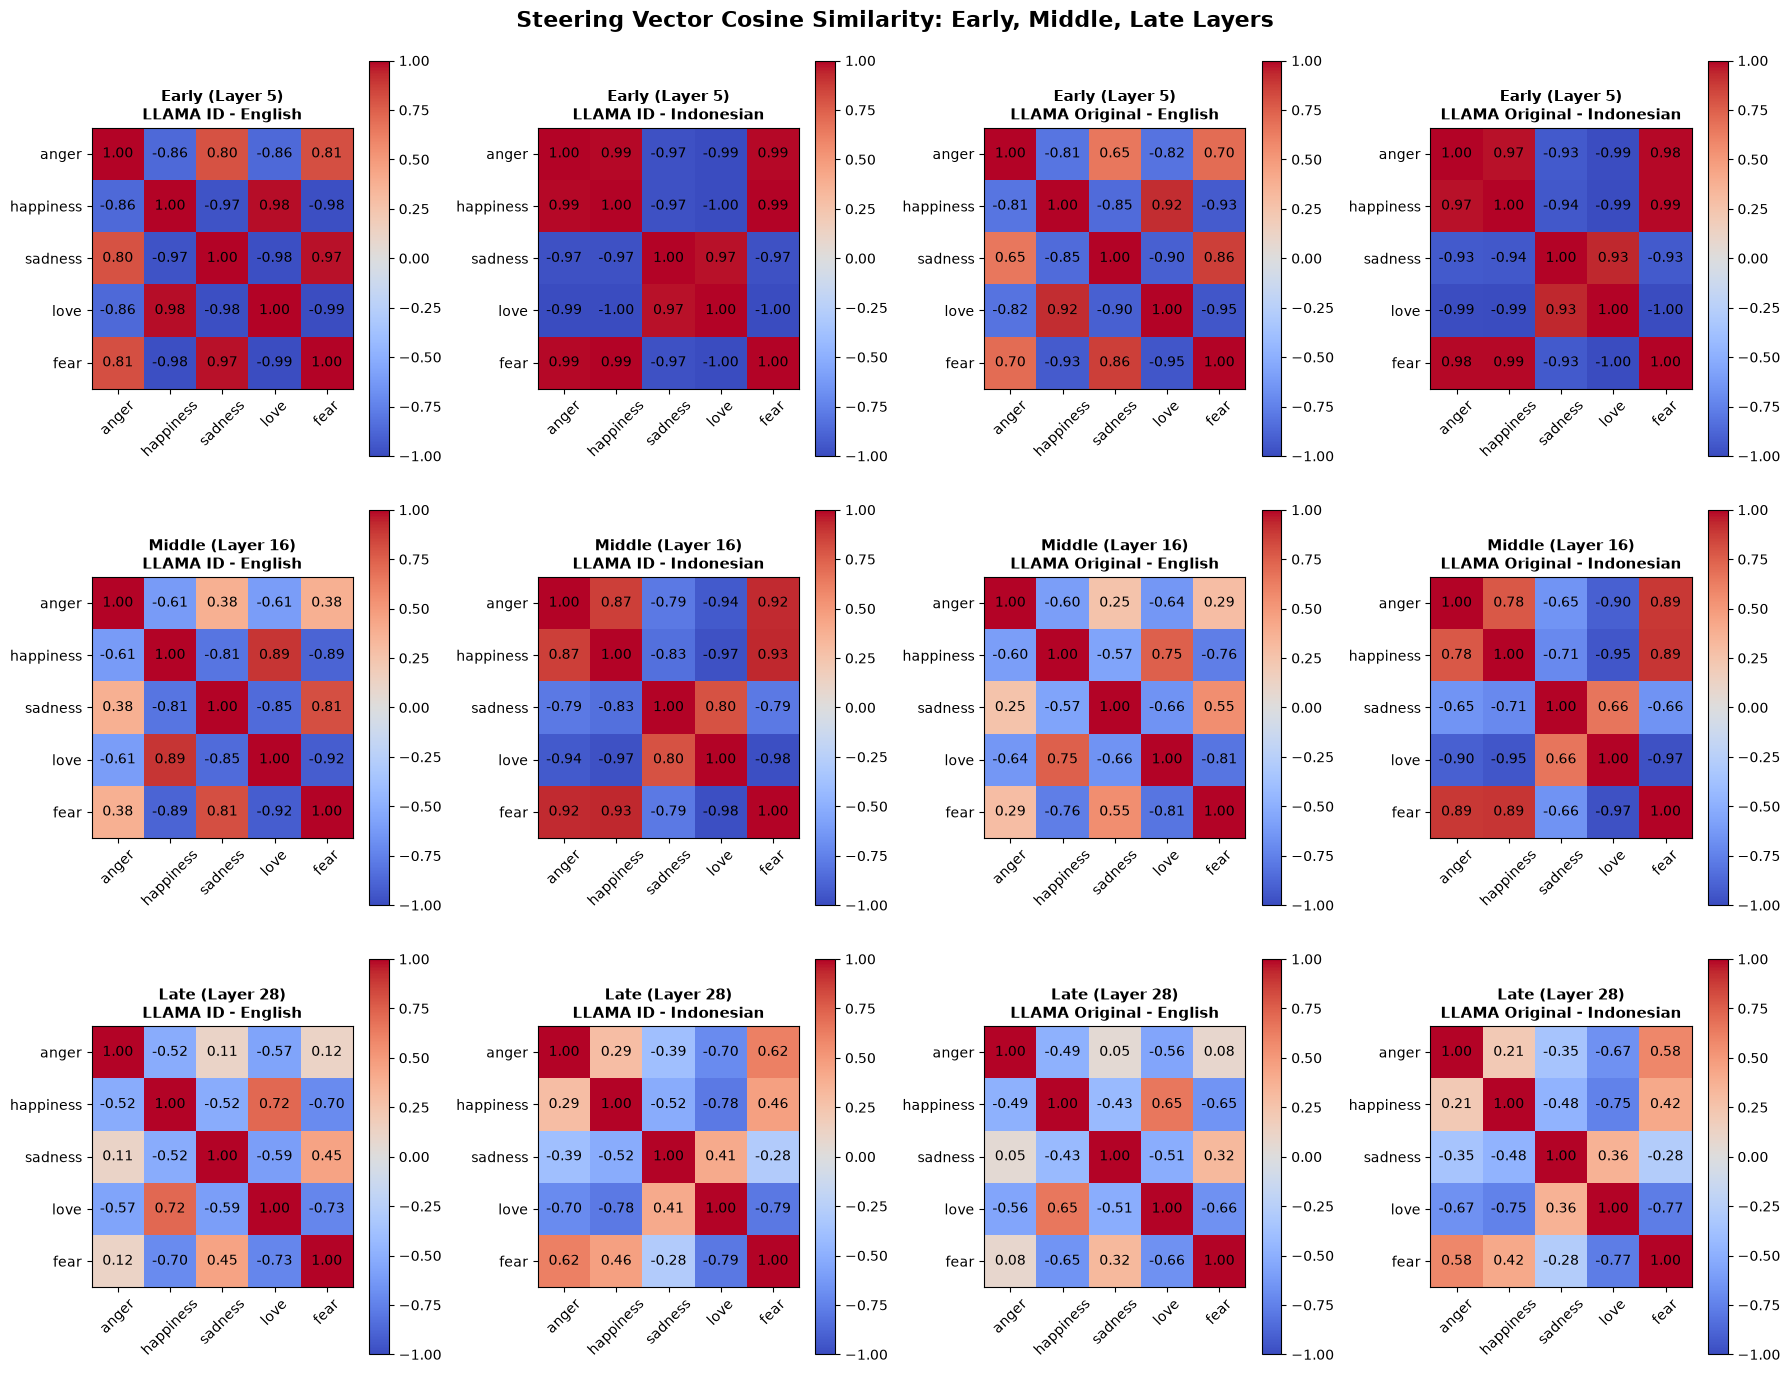

In [7]:

# Cosine matrices across early, middle, and late layers
layer_selection = [5, 16, 28]
layer_labels = ['Early (Layer 5)', 'Middle (Layer 16)', 'Late (Layer 28)']

fig, axes = plt.subplots(3, 4, figsize=(18, 14))

for row, (layer_idx, layer_label) in enumerate(zip(layer_selection, layer_labels)):
    # Build cosine matrices for this layer
    llamaid_eng_matrix = analysis.build_cosine_matrix(Llama_indo_steering_vector_eng, emotions, layer_idx)
    llamaid_id_matrix = analysis.build_cosine_matrix(Llama_indo_steering_vector_id, emotions, layer_idx)
    llamaeng_eng_matrix = analysis.build_cosine_matrix(Llama_eng_steering_vector_eng, emotions, layer_idx)
    llamaeng_id_matrix = analysis.build_cosine_matrix(Llama_eng_steering_vector_id, emotions, layer_idx)
    
    # Column 0: LLAMA ID - English
    im0 = axes[row, 0].imshow(llamaid_eng_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
    axes[row, 0].set_xticks(range(len(emotions)))
    axes[row, 0].set_yticks(range(len(emotions)))
    axes[row, 0].set_xticklabels(emotions, rotation=45)
    axes[row, 0].set_yticklabels(emotions)
    axes[row, 0].set_title(f'{layer_label}\nLLAMA ID - English', fontsize=11, fontweight='bold')
    analysis.annotate_heatmap(axes[row, 0], llamaid_eng_matrix.values)
    plt.colorbar(im0, ax=axes[row, 0])
    
    # Column 1: LLAMA ID - Indonesian
    im1 = axes[row, 1].imshow(llamaid_id_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
    axes[row, 1].set_xticks(range(len(emotions)))
    axes[row, 1].set_yticks(range(len(emotions)))
    axes[row, 1].set_xticklabels(emotions, rotation=45)
    axes[row, 1].set_yticklabels(emotions)
    axes[row, 1].set_title(f'{layer_label}\nLLAMA ID - Indonesian', fontsize=11, fontweight='bold')
    analysis.annotate_heatmap(axes[row, 1], llamaid_id_matrix.values)
    plt.colorbar(im1, ax=axes[row, 1])
    
    # Column 2: LLAMA Original - English
    im2 = axes[row, 2].imshow(llamaeng_eng_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
    axes[row, 2].set_xticks(range(len(emotions)))
    axes[row, 2].set_yticks(range(len(emotions)))
    axes[row, 2].set_xticklabels(emotions, rotation=45)
    axes[row, 2].set_yticklabels(emotions)
    axes[row, 2].set_title(f'{layer_label}\nLLAMA Original - English', fontsize=11, fontweight='bold')
    analysis.annotate_heatmap(axes[row, 2], llamaeng_eng_matrix.values)
    plt.colorbar(im2, ax=axes[row, 2])
    
    # Column 3: LLAMA Original - Indonesian
    im3 = axes[row, 3].imshow(llamaeng_id_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
    axes[row, 3].set_xticks(range(len(emotions)))
    axes[row, 3].set_yticks(range(len(emotions)))
    axes[row, 3].set_xticklabels(emotions, rotation=45)
    axes[row, 3].set_yticklabels(emotions)
    axes[row, 3].set_title(f'{layer_label}\nLLAMA Original - Indonesian', fontsize=11, fontweight='bold')
    analysis.annotate_heatmap(axes[row, 3], llamaeng_id_matrix.values)
    plt.colorbar(im3, ax=axes[row, 3])

plt.suptitle('Steering Vector Cosine Similarity: Early, Middle, Late Layers', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## Cosine Similarity Statistical Test 

# Cosine Similarity across layers 

,emotion,layer,cosine_similarity
0,anger,0,0.262442
1,anger,1,0.986448
2,anger,2,0.968251
3,anger,3,0.919748
4,anger,4,0.855297


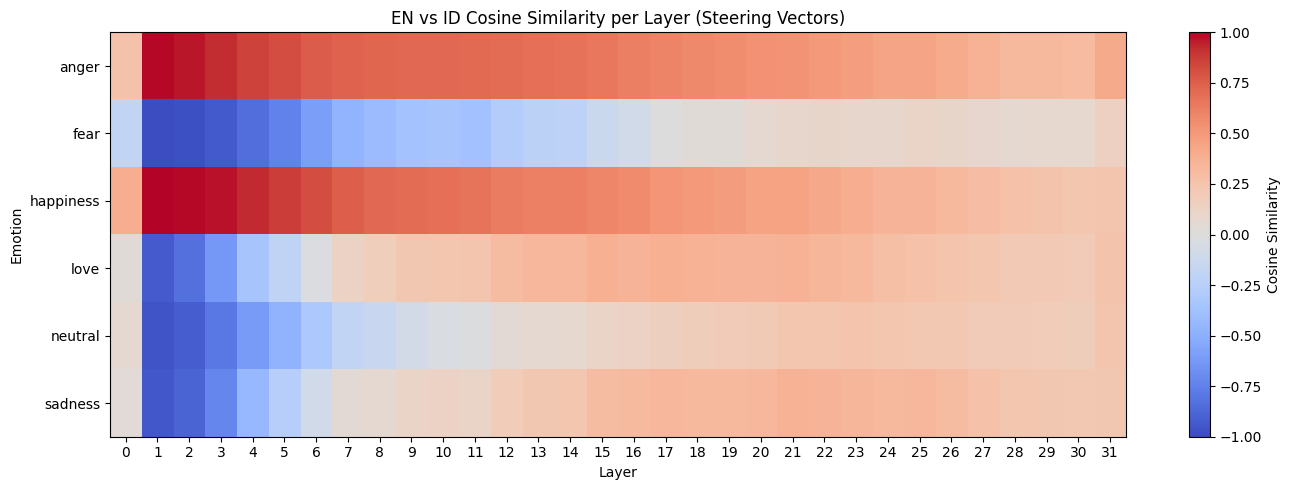

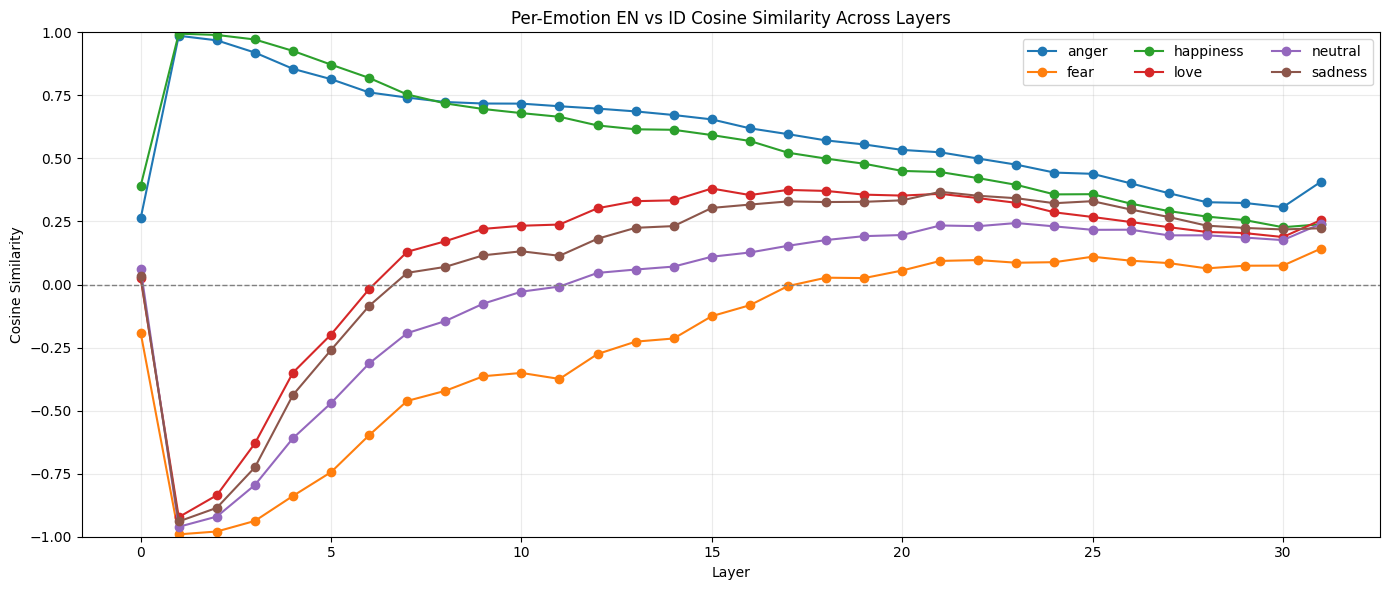

,mean,min,max
emotion,,,
anger,0.602258,0.262442,0.986448
happiness,0.563509,0.227269,0.994790
love,0.129181,-0.922400,0.380684
sadness,0.091719,-0.939441,0.367609
neutral,-0.029900,-0.960747,0.243885
fear,-0.220618,-0.990620,0.142518


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Cosine similarity per layer between EN and ID steering vectors for each emotion
emotions = ["anger", "happiness", "sadness", "love", "fear", "neutral"]
available_emotions = [
    e for e in emotions
    if e in steering_vector_eng and e in steering_vector_id
]

records = []
for emotion in available_emotions:
    en_vec = steering_vector_eng[emotion]
    id_vec = steering_vector_id[emotion]

    if en_vec.shape != id_vec.shape:
        raise ValueError(
            f"Shape mismatch for emotion '{emotion}': EN {en_vec.shape} vs ID {id_vec.shape}"
        )

    layer_sims = F.cosine_similarity(en_vec, id_vec, dim=1)
    for layer_idx, sim in enumerate(layer_sims.tolist()):
        records.append(
            {
                "emotion": emotion,
                "layer": layer_idx,
                "cosine_similarity": sim,
            }
        )

cosine_df = pd.DataFrame(records)
display(cosine_df.head())

# Pivot for heatmap-like matrix: rows = emotions, cols = layers
heatmap_df = cosine_df.pivot(index="emotion", columns="layer", values="cosine_similarity")

plt.figure(figsize=(14, 5))
plt.imshow(heatmap_df.values, aspect="auto", interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Cosine Similarity")
plt.yticks(ticks=np.arange(len(heatmap_df.index)), labels=heatmap_df.index)
plt.xticks(ticks=np.arange(len(heatmap_df.columns)), labels=heatmap_df.columns)
plt.xlabel("Layer")
plt.ylabel("Emotion")
plt.title("EN vs ID Cosine Similarity per Layer (Steering Vectors)")
plt.tight_layout()
plt.show()

# Line plot per emotion across layers
plt.figure(figsize=(14, 6))
for emotion in heatmap_df.index:
    plt.plot(heatmap_df.columns, heatmap_df.loc[emotion].values, marker="o", linewidth=1.5, label=emotion)

plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.ylim(-1, 1)
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Per-Emotion EN vs ID Cosine Similarity Across Layers")
plt.legend(loc="best", ncol=3)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Optional summary table (mean/min/max similarity per emotion)
summary_df = (
    cosine_df.groupby("emotion")["cosine_similarity"]
    .agg(["mean", "min", "max"])
    .sort_values("mean", ascending=False)
)
display(summary_df)

BIDIRECTIONAL TRANSFER: CLEAN COMPARISON

[1] Training probe on ENGLISH data...
Epoch 1/25, Loss: 1.5615
Validation Accuracy: 0.4637
Epoch 2/25, Loss: 1.3951
Validation Accuracy: 0.5950
Epoch 3/25, Loss: 1.2686
Validation Accuracy: 0.5875
Epoch 4/25, Loss: 1.1826
Validation Accuracy: 0.6288
Epoch 5/25, Loss: 1.1018
Validation Accuracy: 0.6312
Epoch 6/25, Loss: 1.0380
Validation Accuracy: 0.6175
Epoch 7/25, Loss: 0.9781
Validation Accuracy: 0.6238
Epoch 8/25, Loss: 0.9282
Validation Accuracy: 0.6362
Epoch 9/25, Loss: 0.8969
Validation Accuracy: 0.6562
Epoch 10/25, Loss: 0.8576
Validation Accuracy: 0.6613
Epoch 11/25, Loss: 0.8244
Validation Accuracy: 0.6713
Epoch 12/25, Loss: 0.7987
Validation Accuracy: 0.6650
Epoch 13/25, Loss: 0.7739
Validation Accuracy: 0.6625
Epoch 14/25, Loss: 0.7531
Validation Accuracy: 0.6750
Epoch 15/25, Loss: 0.7319
Validation Accuracy: 0.6587
Epoch 16/25, Loss: 0.7090
Validation Accuracy: 0.6713
Epoch 17/25, Loss: 0.6916
Validation Accuracy: 0.6725
Epoch 18/25

,Direction,Accuracy
0,EN → EN,0.67625
1,EN → ID,0.69500
2,ID → ID,0.90250
3,ID → EN,0.50500


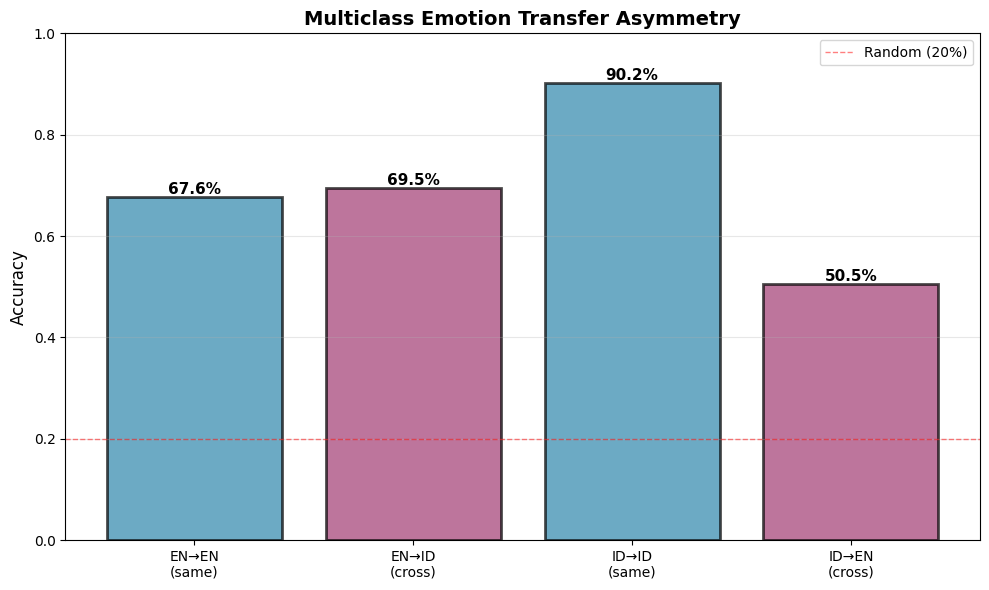

In [21]:
# Clean bidirectional transfer analysis
import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("BIDIRECTIONAL TRANSFER: CLEAN COMPARISON")
print("="*70)

# Train probe on ENGLISH
print("\n[1] Training probe on ENGLISH data...")
probe_en_fresh = analysis.LogisticRegressionProbe(
    input_dim=emotion_vector_eng[all_emotions[0]][0].shape[-1],
    output_dim=len(all_emotions),
)
probe_en_fresh = analysis.trainMultiClassProbe(
    probe_en_fresh, emotion_data_eng_train, emotion_data_eng_val, num_epochs=25
)

en_self = float(analysis.predictProbe(probe_en_fresh, emotion_data_eng_val, multiclass=True).mean())
en_to_id = float(analysis.predictProbe(probe_en_fresh, emotion_data_id_val, multiclass=True).mean())
print(f"EN trained, tested on EN: {en_self:.4f}")
print(f"EN trained, tested on ID: {en_to_id:.4f}")
print(f"Transfer drop EN→ID: {en_self - en_to_id:.4f}")

# Train probe on INDONESIAN  
print("\n[2] Training probe on INDONESIAN data...")
probe_id_fresh = analysis.LogisticRegressionProbe(
    input_dim=emotion_vector_id[all_emotions[0]][0].shape[-1],
    output_dim=len(all_emotions),
)
probe_id_fresh = analysis.trainMultiClassProbe(
    probe_id_fresh, emotion_data_id_train, emotion_data_id_val, num_epochs=25
)

id_self = float(analysis.predictProbe(probe_id_fresh, emotion_data_id_val, multiclass=True).mean())
id_to_en = float(analysis.predictProbe(probe_id_fresh, emotion_data_eng_val, multiclass=True).mean())
print(f"ID trained, tested on ID: {id_self:.4f}")
print(f"ID trained, tested on EN: {id_to_en:.4f}")
print(f"Transfer drop ID→EN: {id_self - id_to_en:.4f}")

# Summary comparison
print("\n" + "="*70)
print("TRANSFER SUMMARY")
print("="*70)
transfer_summary = pd.DataFrame({
    'Direction': ['EN → EN', 'EN → ID', 'ID → ID', 'ID → EN'],
    'Accuracy': [en_self, en_to_id, id_self, id_to_en],
})
display(transfer_summary)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
directions = ['EN→EN\n(same)', 'EN→ID\n(cross)', 'ID→ID\n(same)', 'ID→EN\n(cross)']
accuracies = [en_self, en_to_id, id_self, id_to_en]
colors = ['#2E86AB', '#A23B72', '#2E86AB', '#A23B72']

bars = ax.bar(directions, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Multiclass Emotion Transfer Asymmetry', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.axhline(0.2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Random (20%)')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.show()